# Kagan Group — Exploratory Data Analysis
### ML-I Final Project | Team 7

**Goal of this project:** Understand customer purchase behavior and product relationships deeply enough to justify and inform our recommendation system design.

**Two core questions we're answering:**
1. **Product Analysis** — What products exist, how are they structured, which ones drive revenue, and which ones naturally go together?
2. **Customer Purchase Behavior** — How do customers shop, what patterns exist, and can we segment them meaningfully?

- Section 1: Product Analysis
- Section 2: Customer Purchase Behavior  
- Section 3: Co-purchase & Complementary Product Analysis
- Section 4: Feature Importance (Random Forest)
- Section 5: Key Findings Summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations
from scipy import stats
import joblib
import os
import time

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [40]:
# %pip install openpyxl
# %pip install xlrd

In [3]:
# 1. Define folder and file separately
folder = "/Users/bestek/Desktop/UChicago/Winter'26/ADSP 31017 - ML I/Final Project/clean_data"
customer = 'clean_customers.csv'
order = 'clean_orders.csv'
product = 'clean_products.csv'
final_df = 'final_clean_df.csv'


# 2. Combine them securely
file_customer = os.path.join(folder, customer)
file_order = os.path.join(folder, order) 
file_product = os.path.join(folder, product) 
file_final_df = os.path.join(folder, final_df) 

customers = pd.read_csv(file_customer)
orders = pd.read_csv(file_order)
products = pd.read_csv(file_product)
df = pd.read_csv(file_final_df)

print(f"Customer Dataset loaded: {customers.shape[0]} rows and {customers.shape[1]} columns")
print(f"Order Dataset loaded: {orders.shape[0]} rows and {orders.shape[1]} columns")
print(f"Product Dataset loaded: {products.shape[0]} rows and {products.shape[1]} columns")
print(f"Combined Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")

Customer Dataset loaded: 18070 rows and 7 columns
Order Dataset loaded: 97702 rows and 11 columns
Product Dataset loaded: 14784 rows and 15 columns
Combined Dataset loaded: 97702 rows and 31 columns


In [5]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

print(f'Shape: {df.shape}')
print(f'Date range: {df["purchase_date"].min()} -> {df["purchase_date"].max()}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\Data Trype: {df.dtypes}')

Shape: (97702, 31)
Date range: 2024-01-01 00:00:00 -> 2026-02-18 00:00:00

Columns: ['customer_id', 'order_id', 'product_code', 'product_name', 'quantity', 'unit_price', 'purchase_date', 'line_total', 'is_gift', 'is_subproduct', 'is_member', 'category_main', 'category_mid', 'category_sub', 'full_path', 'price_original', 'price_discounted', 'brand', 'discount_pct', 'price_anomaly', 'ever_purchased', 'avg_consumption_days', 'consumption_bucket', 'price_tier', 'total_orders', 'total_products_bought', 'total_spend_tl', 'tenure_bucket', 'est_returns', 'has_returned', 'missing_product_info']
\Data Trype: customer_id                      object
order_id                         object
product_code                     object
product_name                     object
quantity                          int64
unit_price                      float64
purchase_date            datetime64[ns]
line_total                      float64
is_gift                            bool
is_subproduct                     

In [6]:
# Data Quality Check
# Before any analysis, understand what's missing and what's complete

print('Data Quality Report')
print(f'Total transactions: {len(df):,}')
print(f'Unique customers: {df["customer_id"].nunique():,}')
print(f'Unique orders: {df["order_id"].nunique():,}')
print(f'Unique products: {df["product_code"].nunique():,}')
print(f'Date range: {df["purchase_date"].min().date()} to {df["purchase_date"].max().date()}')
print()

# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

if len(missing_df) > 0:
    print('Columns with missing values:')
    print(missing_df)
else:
    print('No missing values found!')

Data Quality Report
Total transactions: 97,702
Unique customers: 32,663
Unique orders: 51,216
Unique products: 10,135
Date range: 2024-01-01 to 2026-02-18

Columns with missing values:
                       missing_count  missing_pct
total_orders                   24438        25.00
total_products_bought          24438        25.00
total_spend_tl                 24438        25.00
tenure_bucket                  24438        25.00
est_returns                    24438        25.00
has_returned                   24438        25.00
category_mid                   12421        12.70
category_main                   1342         1.40
brand                              1         0.00


---
## Section 1: Product Analysis

### Q1.1 — What does our product catalog look like?
what categories and brands we're working with and where is the revenue concentration

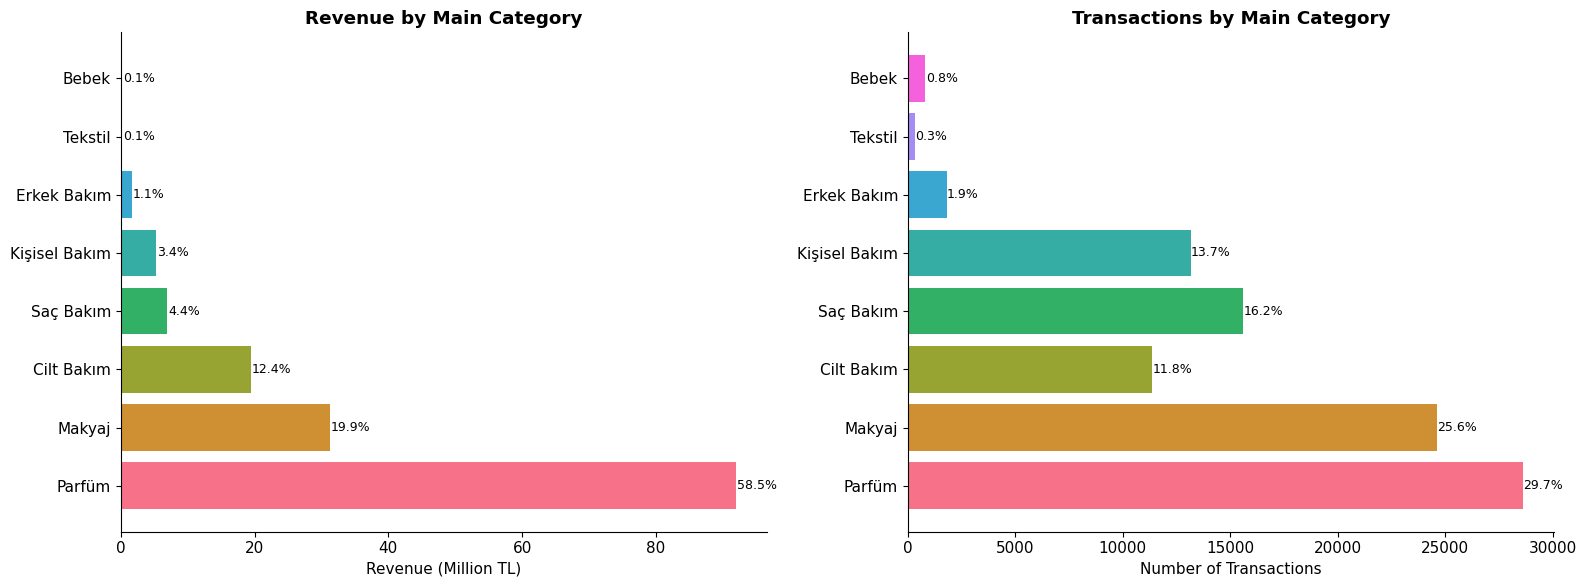

category_main  total_revenue  revenue_pct  unique_products  unique_customers
       Parfüm    91974249.53        58.50             2198             16124
       Makyaj    31278716.35        19.90             3837              8749
   Cilt Bakım    19517507.64        12.40              854              4528
    Saç Bakım     6967558.73         4.40             1323              5852
Kişisel Bakım     5281830.95         3.40             1299              4791
  Erkek Bakım     1736447.43         1.10              133               867
      Tekstil      206778.76         0.10              214               166
        Bebek      195533.91         0.10              122               473


In [7]:
# Revenue and transaction share by main category
category_stats = df.groupby('category_main').agg(
    total_revenue=('line_total', 'sum'),
    total_transactions=('order_id', 'count'),
    unique_products=('product_code', 'nunique'),
    unique_customers=('customer_id', 'nunique')
).sort_values('total_revenue', ascending=False).reset_index()

category_stats['revenue_pct'] = (category_stats['total_revenue'] / category_stats['total_revenue'].sum() * 100).round(1)
category_stats['transaction_pct'] = (category_stats['total_transactions'] / category_stats['total_transactions'].sum() * 100).round(1)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by category
axes[0].barh(category_stats['category_main'], category_stats['total_revenue'] / 1e6, color=sns.color_palette('husl', len(category_stats)))
axes[0].set_xlabel('Revenue (Million TL)')
axes[0].set_title('Revenue by Main Category', fontweight='bold')
for i, (val, pct) in enumerate(zip(category_stats['total_revenue'], category_stats['revenue_pct'])):
    axes[0].text(val/1e6 + 0.1, i, f'{pct}%', va='center', fontsize=9)

# Transactions by category
axes[1].barh(category_stats['category_main'], category_stats['total_transactions'], color=sns.color_palette('husl', len(category_stats)))
axes[1].set_xlabel('Number of Transactions')
axes[1].set_title('Transactions by Main Category', fontweight='bold')
for i, (val, pct) in enumerate(zip(category_stats['total_transactions'], category_stats['transaction_pct'])):
    axes[1].text(val + 10, i, f'{pct}%', va='center', fontsize=9)


plt.tight_layout()
plt.savefig('fig_01_category_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(category_stats[['category_main', 'total_revenue', 'revenue_pct', 'unique_products', 'unique_customers']].to_string(index=False))

### Q1.2 — Which products and brands drive the most revenue and has the highest selling volume?
The 80/20 rule likely applies here — a small number of products probably drive most of the revenue. This tells us where collaborative filtering will be most reliable (high-frequency products have richer co-purchase signals).

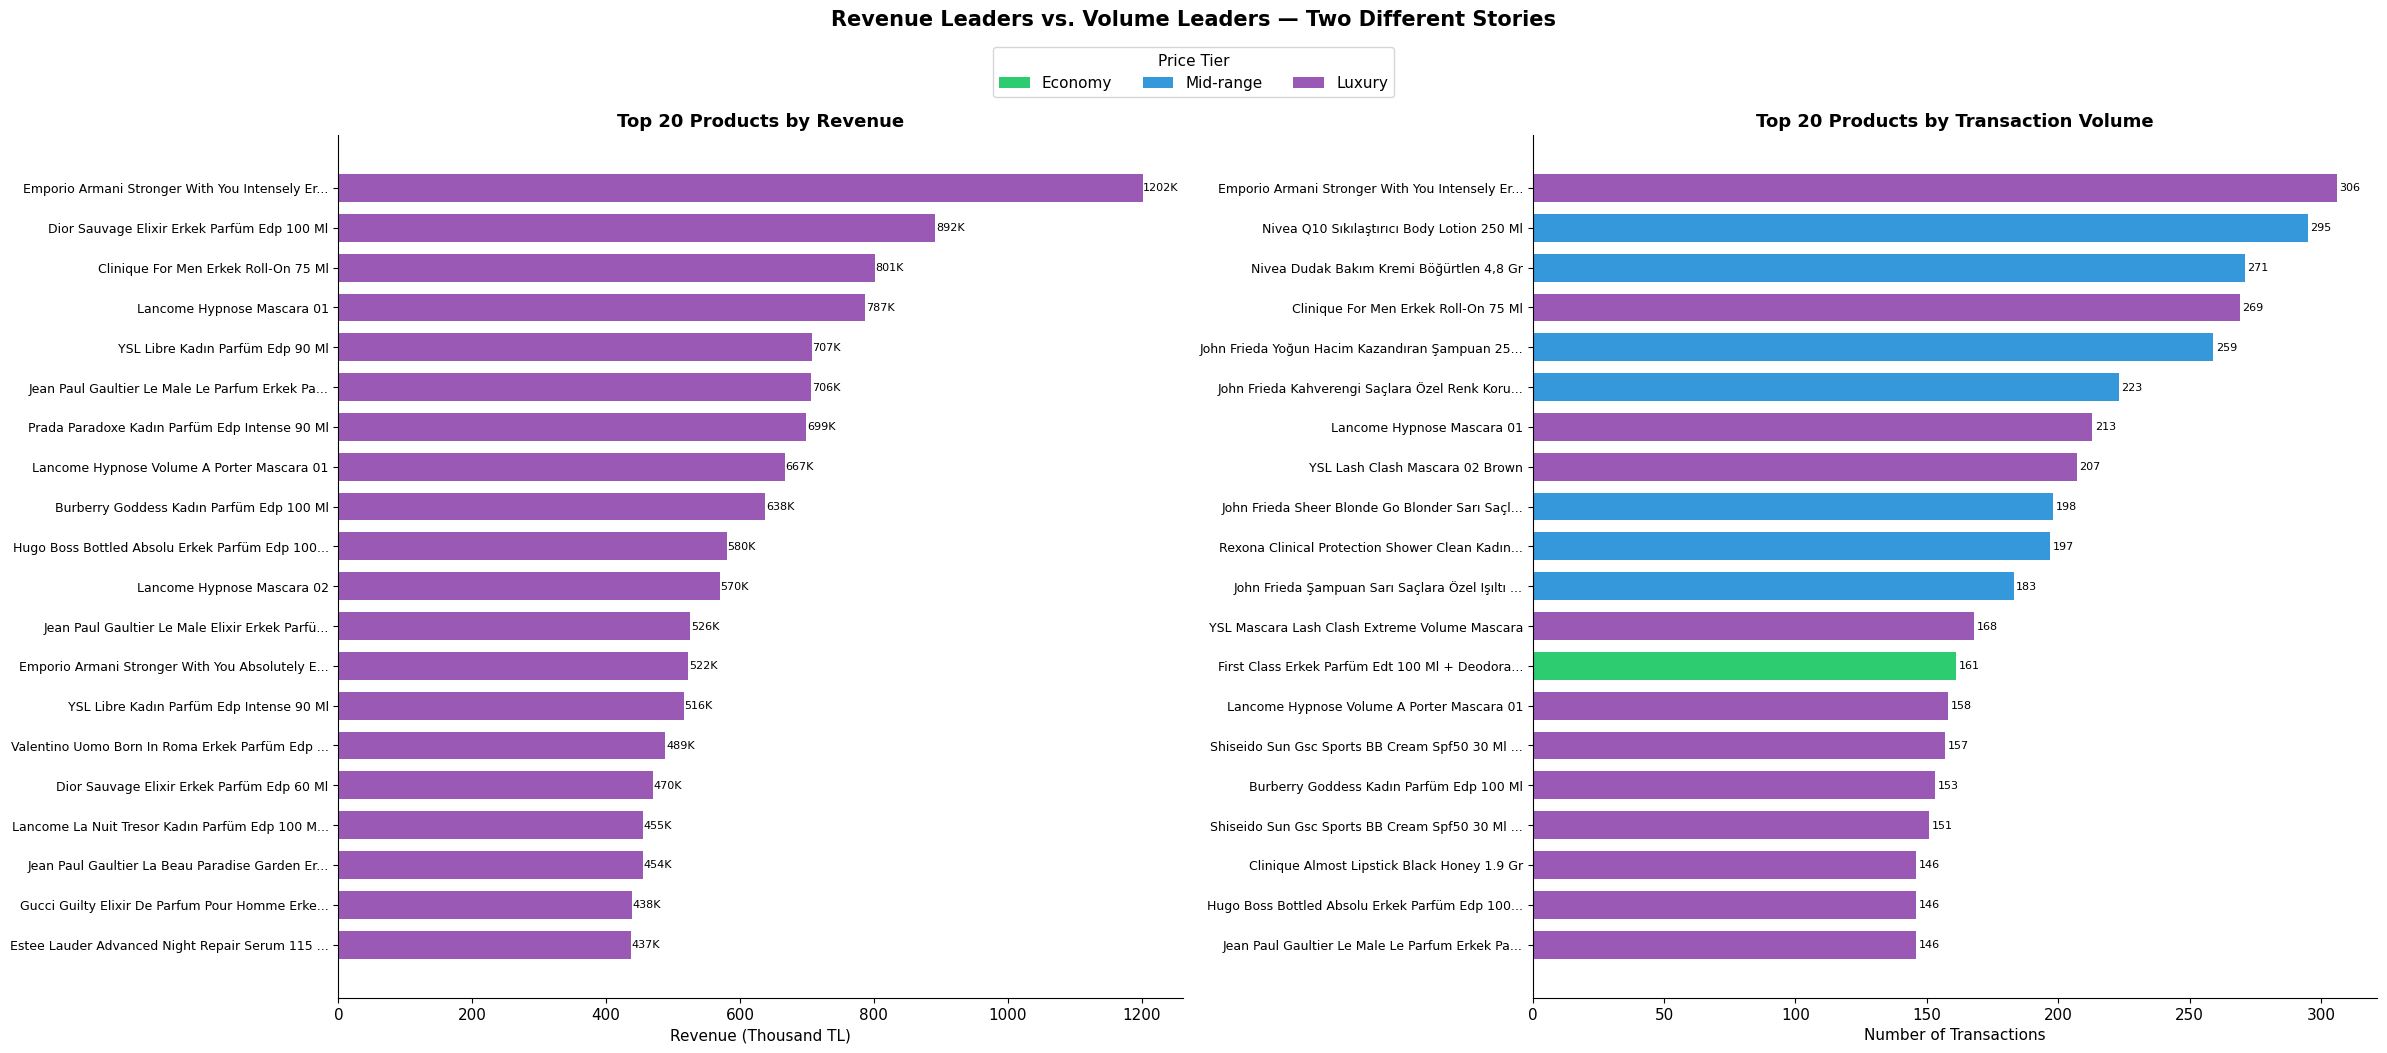

Products in both top 20s: 7
  • Burberry Goddess Kadın Parfüm Edp 100 Ml
  • Clinique For Men Erkek Roll-On 75 Ml
  • Emporio Armani Stronger With You Intensely Erkek Parfüm Edp 100 Ml
  • Hugo Boss Bottled Absolu Erkek Parfüm Edp 100 Ml
  • Jean Paul Gaultier Le Male Le Parfum Erkek Parfüm Edp 125 Ml
  • Lancome Hypnose Mascara 01
  • Lancome Hypnose Volume A Porter Mascara 01

Only in Revenue top 20 (expensive but low volume): 13
Only in Transaction top 20 (high volume but affordable): 13


In [8]:
# Get price tier per product
product_tier = (df.groupby('product_code')['price_tier']
                .agg(lambda x: x.mode()[0])
                .reset_index())

# Top 20 by revenue
top20_revenue = (df.groupby(['product_code', 'product_name'])
                 .agg(revenue=('line_total', 'sum'))
                 .sort_values('revenue', ascending=False)
                 .head(20)
                 .reset_index()
                 .merge(product_tier, on='product_code')
                 .sort_values('revenue', ascending=True))  # ascending for barh display

# Top 20 by transactions
top20_txn = (df.groupby(['product_code', 'product_name'])
             .agg(transactions=('order_id', 'count'))
             .sort_values('transactions', ascending=False)
             .head(20)
             .reset_index()
             .merge(product_tier, on='product_code')
             .sort_values('transactions', ascending=True))

tier_colors = {'Economy': '#2ecc71', 'Mid-range': '#3498db', 'Luxury': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Left: Top 20 by Revenue
colors_rev = [tier_colors.get(t, '#95a5a6') for t in top20_revenue['price_tier']]
bars_left = axes[0].barh(
    range(len(top20_revenue)),
    top20_revenue['revenue'] / 1000,
    color=colors_rev,
    height=0.7
)
axes[0].set_yticks(range(len(top20_revenue)))
axes[0].set_yticklabels(
    [name[:45] + '...' if len(name) > 45 else name 
     for name in top20_revenue['product_name']], 
    fontsize=9
)
axes[0].set_xlabel('Revenue (Thousand TL)')
axes[0].set_title('Top 20 Products by Revenue', fontweight='bold', fontsize=13)

# Add value labels
for bar, val in zip(bars_left, top20_revenue['revenue']):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val/1000:.0f}K', va='center', fontsize=8)

# Right: Top 20 by Transactions
colors_txn = [tier_colors.get(t, '#95a5a6') for t in top20_txn['price_tier']]
bars_right = axes[1].barh(
    range(len(top20_txn)),
    top20_txn['transactions'],
    color=colors_txn,
    height=0.7
)
axes[1].set_yticks(range(len(top20_txn)))
axes[1].set_yticklabels(
    [name[:45] + '...' if len(name) > 45 else name 
     for name in top20_txn['product_name']], 
    fontsize=9
)
axes[1].set_xlabel('Number of Transactions')
axes[1].set_title('Top 20 Products by Transaction Volume', fontweight='bold', fontsize=13)

# Add value labels
for bar, val in zip(bars_right, top20_txn['transactions']):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# Shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
fig.legend(handles=legend_elements, loc='upper center',
           bbox_to_anchor=(0.5, 1.02), ncol=3,
           title='Price Tier', fontsize=11, title_fontsize=11)

plt.suptitle('Revenue Leaders vs. Volume Leaders — Two Different Stories',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig_02_top20_products_two_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

# Who appears in both lists?
overlap = set(top20_revenue['product_name']) & set(top20_txn['product_name'])
only_rev = set(top20_revenue['product_name']) - set(top20_txn['product_name'])
only_vol = set(top20_txn['product_name']) - set(top20_revenue['product_name'])

print(f"Products in both top 20s: {len(overlap)}")
for p in sorted(overlap): print(f"  • {p}")
print(f"\nOnly in Revenue top 20 (expensive but low volume): {len(only_rev)}")
print(f"Only in Transaction top 20 (high volume but affordable): {len(only_vol)}")

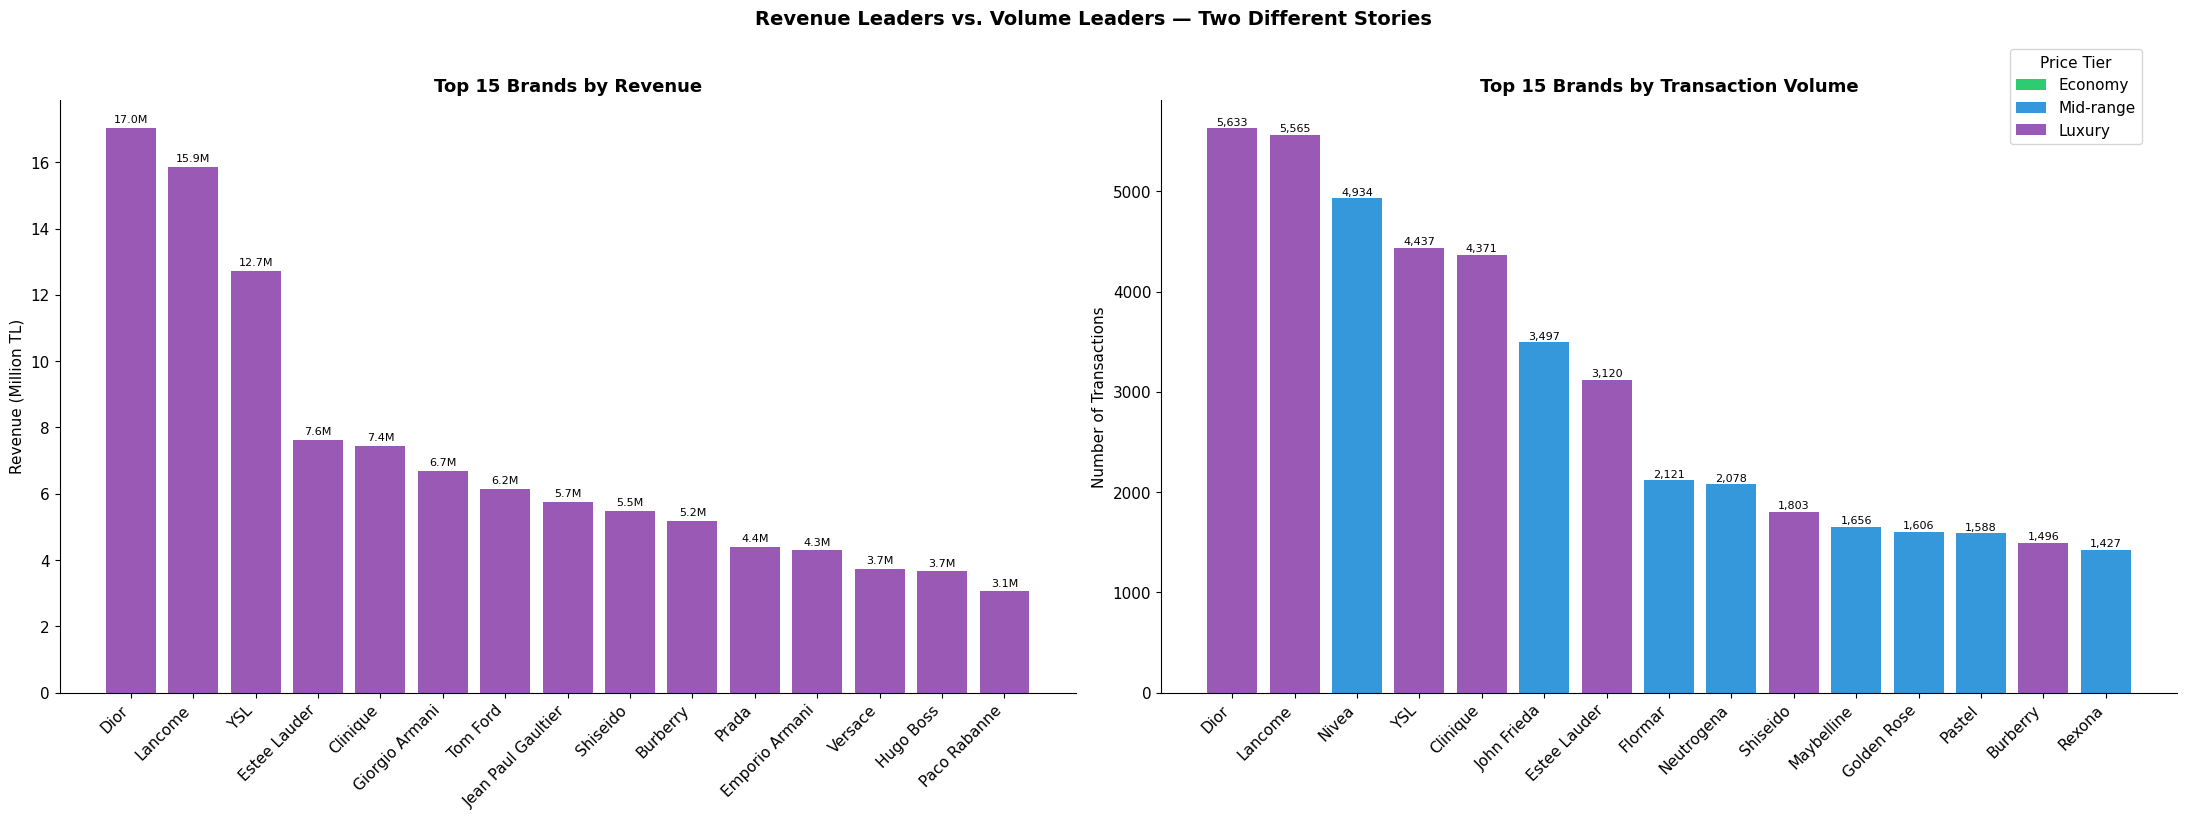

Brands in both top 15s: ['Burberry', 'Clinique', 'Dior', 'Estee Lauder', 'Lancome', 'Shiseido', 'YSL']

Only in Revenue top 15 (expensive but low volume): ['Emporio Armani', 'Giorgio Armani', 'Hugo Boss', 'Jean Paul Gaultier', 'Paco Rabanne', 'Prada', 'Tom Ford', 'Versace']

Only in Transaction top 15 (high volume but low price): ['Flormar', 'Golden Rose', 'John Frieda', 'Maybelline', 'Neutrogena', 'Nivea', 'Pastel', 'Rexona']


In [9]:
# Two completely independent top 15 lists
top15_by_revenue = (df.groupby('brand')['line_total']
                    .sum()
                    .sort_values(ascending=False)
                    .head(15)
                    .reset_index()
                    .rename(columns={'line_total': 'revenue'}))

top15_by_txn = (df.groupby('brand')['order_id']
                .count()
                .sort_values(ascending=False)
                .head(15)
                .reset_index()
                .rename(columns={'order_id': 'transactions'}))

# Get price tier for each brand
brand_tier = (df.groupby('brand')['price_tier']
              .agg(lambda x: x.mode()[0])
              .reset_index())

top15_by_revenue = top15_by_revenue.merge(brand_tier, on='brand')
top15_by_txn = top15_by_txn.merge(brand_tier, on='brand')

tier_colors = {'Economy': '#2ecc71', 'Mid-range': '#3498db', 'Luxury': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Left: Top 15 by Revenue
colors_rev = [tier_colors.get(t, '#95a5a6') for t in top15_by_revenue['price_tier']]
bars_left = axes[0].bar(top15_by_revenue['brand'], 
                         top15_by_revenue['revenue'] / 1e6, 
                         color=colors_rev)
axes[0].set_title('Top 15 Brands by Revenue', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Revenue (Million TL)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, val in zip(bars_left, top15_by_revenue['revenue']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=8)

# Right: Top 15 by Transactions (independent list)
colors_txn = [tier_colors.get(t, '#95a5a6') for t in top15_by_txn['price_tier']]
bars_right = axes[1].bar(top15_by_txn['brand'], 
                          top15_by_txn['transactions'], 
                          color=colors_txn)
axes[1].set_title('Top 15 Brands by Transaction Volume', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Transactions')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
for bar, val in zip(bars_right, top15_by_txn['transactions']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

# Shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
fig.legend(handles=legend_elements, loc='upper right',
           bbox_to_anchor=(0.98, 0.98), title='Price Tier')

plt.suptitle('Revenue Leaders vs. Volume Leaders — Two Different Stories', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_03_brands_two_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

# Brands that appear in both top 15s
overlap = set(top15_by_revenue['brand']) & set(top15_by_txn['brand'])
only_revenue = set(top15_by_revenue['brand']) - set(top15_by_txn['brand'])
only_txn = set(top15_by_txn['brand']) - set(top15_by_revenue['brand'])

print(f'Brands in both top 15s: {sorted(overlap)}')
print(f'\nOnly in Revenue top 15 (expensive but low volume): {sorted(only_revenue)}')
print(f'\nOnly in Transaction top 15 (high volume but low price): {sorted(only_txn)}')

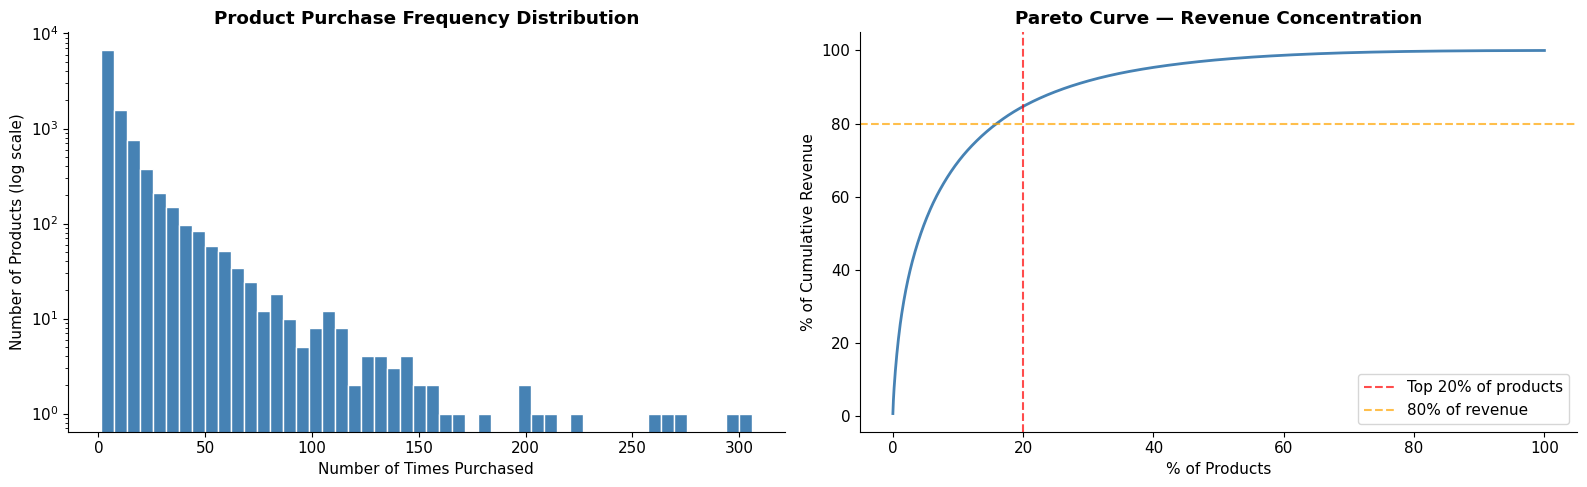

Products bought only once: 1,903 (18.8%)
Products bought fewer than 5 times: 5,077 (50.1%)

Implication: These products have sparse signals for collaborative filtering.
Content-based fallback (category/brand similarity) needed for cold-start products.


In [10]:
# Product long-tail analysis — the cold start problem visualized
# How many products have very few purchases? These are hard to recommend.
purchase_freq = df.groupby('product_code')['order_id'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution of purchase frequency
axes[0].hist(purchase_freq.values, bins=50, color='steelblue', edgecolor='white', log=True)
axes[0].set_xlabel('Number of Times Purchased')
axes[0].set_ylabel('Number of Products (log scale)')
axes[0].set_title('Product Purchase Frequency Distribution', fontweight='bold')

# Cumulative revenue curve (Pareto)
product_revenue = df.groupby('product_code')['line_total'].sum().sort_values(ascending=False)
cumulative_pct = (product_revenue.cumsum() / product_revenue.sum() * 100)
product_pct = np.arange(1, len(cumulative_pct) + 1) / len(cumulative_pct) * 100

axes[1].plot(product_pct, cumulative_pct.values, color='steelblue', linewidth=2)
axes[1].axvline(x=20, color='red', linestyle='--', alpha=0.7, label='Top 20% of products')
axes[1].axhline(y=80, color='orange', linestyle='--', alpha=0.7, label='80% of revenue')
axes[1].set_xlabel('% of Products')
axes[1].set_ylabel('% of Cumulative Revenue')
axes[1].set_title('Pareto Curve — Revenue Concentration', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_04_product_longtail.png', dpi=150, bbox_inches='tight')
plt.show()

# Thresholds
never_purchased = (purchase_freq == 0).sum() if 0 in purchase_freq.values else 0
bought_once = (purchase_freq == 1).sum()
bought_under5 = (purchase_freq < 5).sum()
print(f'Products bought only once: {bought_once:,} ({bought_once/len(purchase_freq)*100:.1f}%)')
print(f'Products bought fewer than 5 times: {bought_under5:,} ({bought_under5/len(purchase_freq)*100:.1f}%)')
print(f'\nImplication: These products have sparse signals for collaborative filtering.')
print(f'Content-based fallback (category/brand similarity) needed for cold-start products.')

Plot on the left: Our catalog has a massive long tail. Most products are rarely purchased. This is the cold-start problem and collaborative filtering struggles with products that have almost no purchase history because there's not enough signal to learn from.

Plot on the right: A small number of products drive almost all your revenue. The remaining 80% of your catalog contributes only the last 20% of revenue.

**Analysis:**
- For the top 20% of products → Collaborative Filtering works perfectly because they have rich purchase history
- For the long tail 80% → Content-based fallback is essential because there's not enough purchase data to learn from, so we rely on category and brand similarity instead



### Q1.3 — How are price tiers and consumption periods distributed?
Understanding price tier and consumption patterns helps us design smarter recommendations — e.g. suggesting a replenishment of a monthly product vs. a luxury upsell.

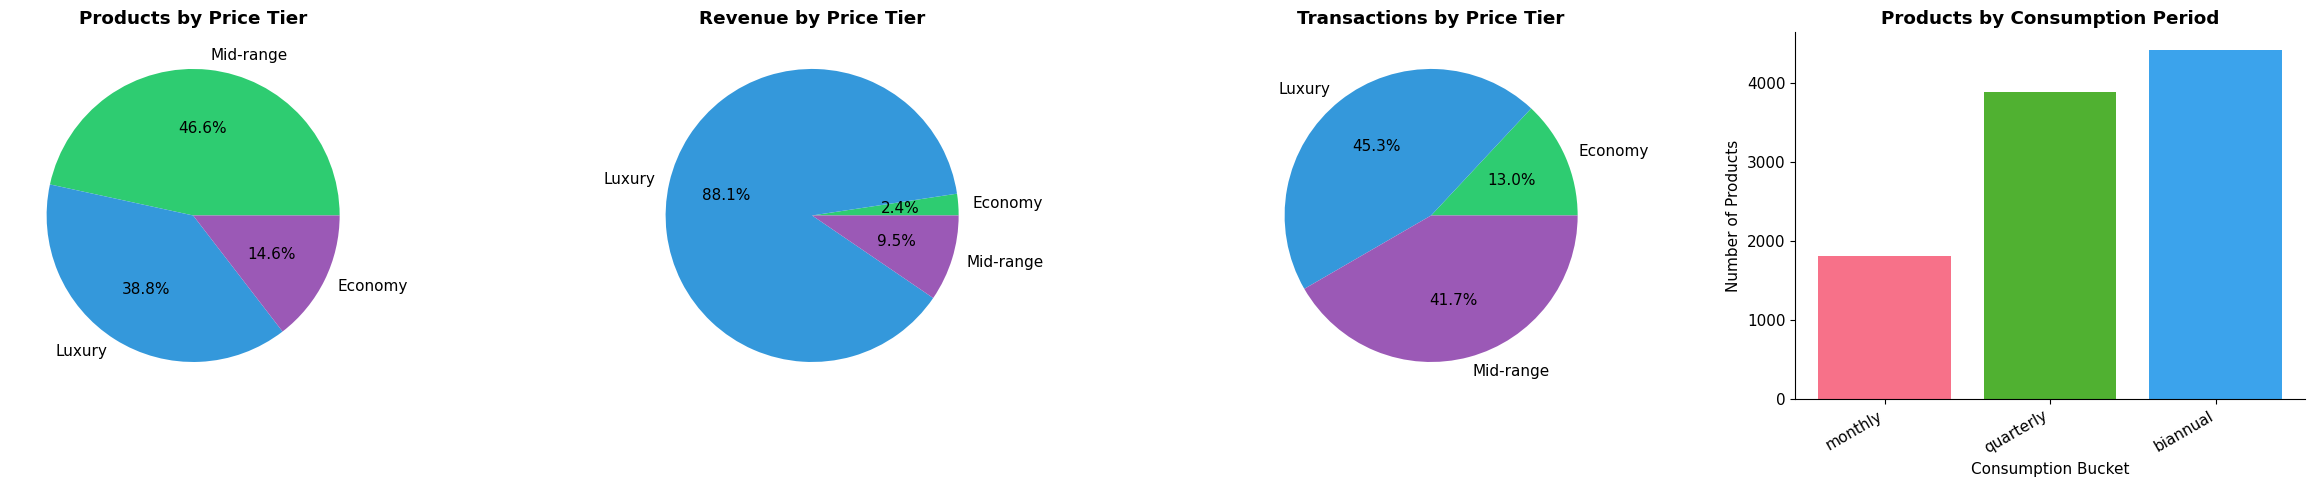

Price Tier Comparison:
            product_pct  revenue_pct  transaction_pct
price_tier                                           
Economy           14.60         2.40            13.00
Luxury            38.80        88.10            45.30
Mid-range         46.60         9.50            41.70


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# Price tier — product count
tier_counts = df.drop_duplicates('product_code')['price_tier'].value_counts()
axes[0].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#3498db', '#9b59b6'])
axes[0].set_title('Products by Price Tier', fontweight='bold')

# Price tier — revenue share
tier_revenue = df.groupby('price_tier')['line_total'].sum()
axes[1].pie(tier_revenue.values, labels=tier_revenue.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#3498db', '#9b59b6'])
axes[1].set_title('Revenue by Price Tier', fontweight='bold')

# Price tier — transaction count
tier_transactions = df.groupby('price_tier')['order_id'].count()
axes[2].pie(tier_transactions.values, labels=tier_transactions.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#3498db', '#9b59b6'])
axes[2].set_title('Transactions by Price Tier', fontweight='bold')

# Consumption bucket distribution
if 'consumption_bucket' in df.columns:
    bucket_order = ['monthly', 'quarterly', 'biannual', 'annual_plus', 'unknown']
    cons_counts = df.drop_duplicates('product_code')['consumption_bucket'].value_counts()
    cons_counts = cons_counts.reindex([b for b in bucket_order if b in cons_counts.index])
    axes[3].bar(cons_counts.index, cons_counts.values, 
                color=sns.color_palette('husl', len(cons_counts)))
    axes[3].set_title('Products by Consumption Period', fontweight='bold')
    axes[3].set_xlabel('Consumption Bucket')
    axes[3].set_ylabel('Number of Products')
    plt.setp(axes[3].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig_05_price_consumption.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers so you can compare all three side by side
print('Price Tier Comparison:')
summary = pd.DataFrame({
    'product_count': tier_counts,
    'revenue':       tier_revenue,
    'transactions':  tier_transactions
})
summary['product_pct'] = (summary['product_count'] / summary['product_count'].sum() * 100).round(1)
summary['revenue_pct'] = (summary['revenue'] / summary['revenue'].sum() * 100).round(1)
summary['transaction_pct'] = (summary['transactions'] / summary['transactions'].sum() * 100).round(1)
print(summary[['product_pct', 'revenue_pct', 'transaction_pct']].to_string())

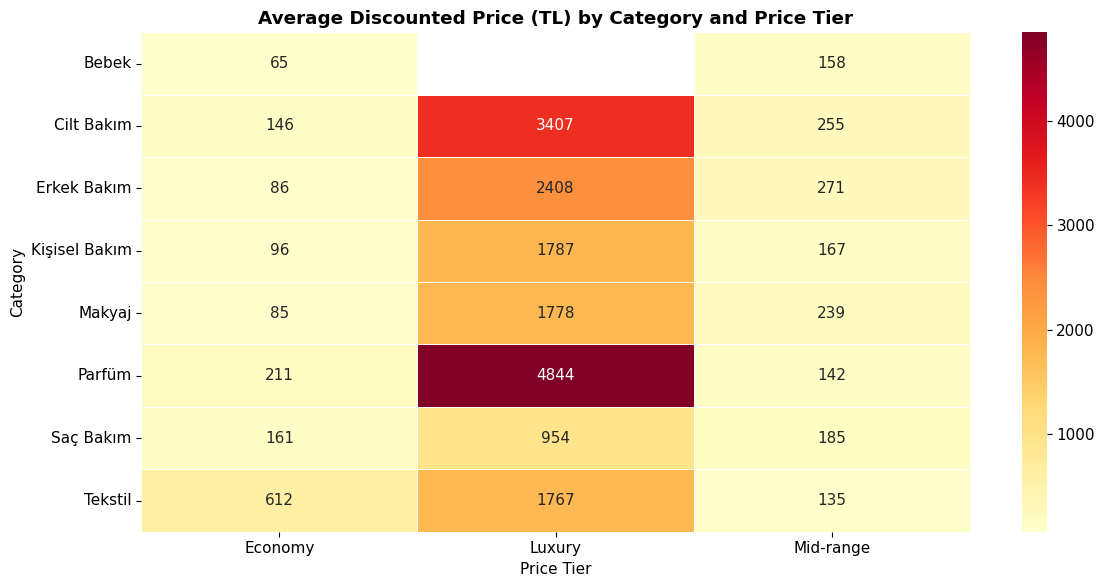

In [12]:
# Average price by category and tier — heatmap
# This tells us: which categories have the widest price range across tiers?
price_heatmap = df.groupby(['category_main', 'price_tier'])['price_discounted'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(price_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average Discounted Price (TL) by Category and Price Tier', fontweight='bold')
ax.set_xlabel('Price Tier')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('fig_06_price_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Customer Purchase Behavior

### Q2.1 — How often do customers buy, and how much do they spend?
This is the foundation of RFM analysis — Recency, Frequency, Monetary value. These three dimensions together describe a customer's value and engagement level.

In [13]:
# Split registered vs unregistered
df['is_registered'] = ~df['customer_id'].astype(str).str.startswith('ts_')

registered = df[df['is_registered']].copy()
unregistered = df[~df['is_registered']].copy()

print(f"Total customers: {df['customer_id'].nunique():,}")
print(f"Registered (T...): {registered['customer_id'].nunique():,}")
print(f"Unregistered (ts_...): {unregistered['customer_id'].nunique():,}")
print(f"Unregistered % of total customers: {unregistered['customer_id'].nunique() / df['customer_id'].nunique() * 100:.1f}%")
print()
print(f"Total transactions: {len(df):,}")
print(f"Registered transactions: {len(registered):,} ({len(registered)/len(df)*100:.1f}%)")
print(f"Unregistered transactions: {len(unregistered):,} ({len(unregistered)/len(df)*100:.1f}%)")

Total customers: 32,663
Registered (T...): 19,152
Unregistered (ts_...): 13,511
Unregistered % of total customers: 41.4%

Total transactions: 97,702
Registered transactions: 76,533 (78.3%)
Unregistered transactions: 21,169 (21.7%)


In [14]:
# Build RFM for registered customers only
snapshot_date = df['purchase_date'].max() + pd.Timedelta(days=1)

rfm_registered = registered.groupby('customer_id').agg(
    recency_days=('purchase_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('line_total', 'sum'),
    avg_order_value=('line_total', lambda x: x.sum() / registered.loc[x.index, 'order_id'].nunique()),
    first_purchase=('purchase_date', 'min'),
    last_purchase=('purchase_date', 'max')
).reset_index()
rfm_registered['active_days'] = (rfm_registered['last_purchase'] - rfm_registered['first_purchase']).dt.days
rfm_registered['customer_type'] = 'Registered'

rfm_unregistered = unregistered.groupby('customer_id').agg(
    recency_days=('purchase_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('line_total', 'sum'),
    avg_order_value=('line_total', lambda x: x.sum() / unregistered.loc[x.index, 'order_id'].nunique()),
    first_purchase=('purchase_date', 'min'),
    last_purchase=('purchase_date', 'max')
).reset_index()
rfm_unregistered['active_days'] = (rfm_unregistered['last_purchase'] - rfm_unregistered['first_purchase']).dt.days
rfm_unregistered['customer_type'] = 'Unregistered'

# Keep full rfm for comparison
rfm = pd.concat([rfm_registered, rfm_unregistered], ignore_index=True)

print("Registered Customers RFM Summary:")
print(rfm_registered[['recency_days', 'frequency', 'monetary', 'avg_order_value']].describe().round(2))
print()
print("Unregistered Customers RFM Summary:")
print(rfm_unregistered[['recency_days', 'frequency', 'monetary', 'avg_order_value']].describe().round(2))

Registered Customers RFM Summary:
       recency_days  frequency   monetary  avg_order_value
count      19152.00   19152.00   19152.00         19152.00
mean         302.04       1.97    6891.59          3290.68
std          230.84      13.03   63628.93          3355.68
min            1.00       1.00       0.00             0.00
25%           95.00       1.00    1099.97           967.96
50%          263.00       1.00    3391.75          2628.95
75%          464.00       2.00    6287.71          4614.51
max          780.00    1269.00 7511558.12         87360.00

Unregistered Customers RFM Summary:
       recency_days  frequency  monetary  avg_order_value
count      13511.00   13511.00  13511.00         13511.00
mean         397.72       1.00   2239.14          2239.14
std          239.01       0.00   2704.75          2704.75
min            1.00       1.00      7.92             7.92
25%          178.00       1.00    416.81           416.81
50%          413.00       1.00   1189.68          

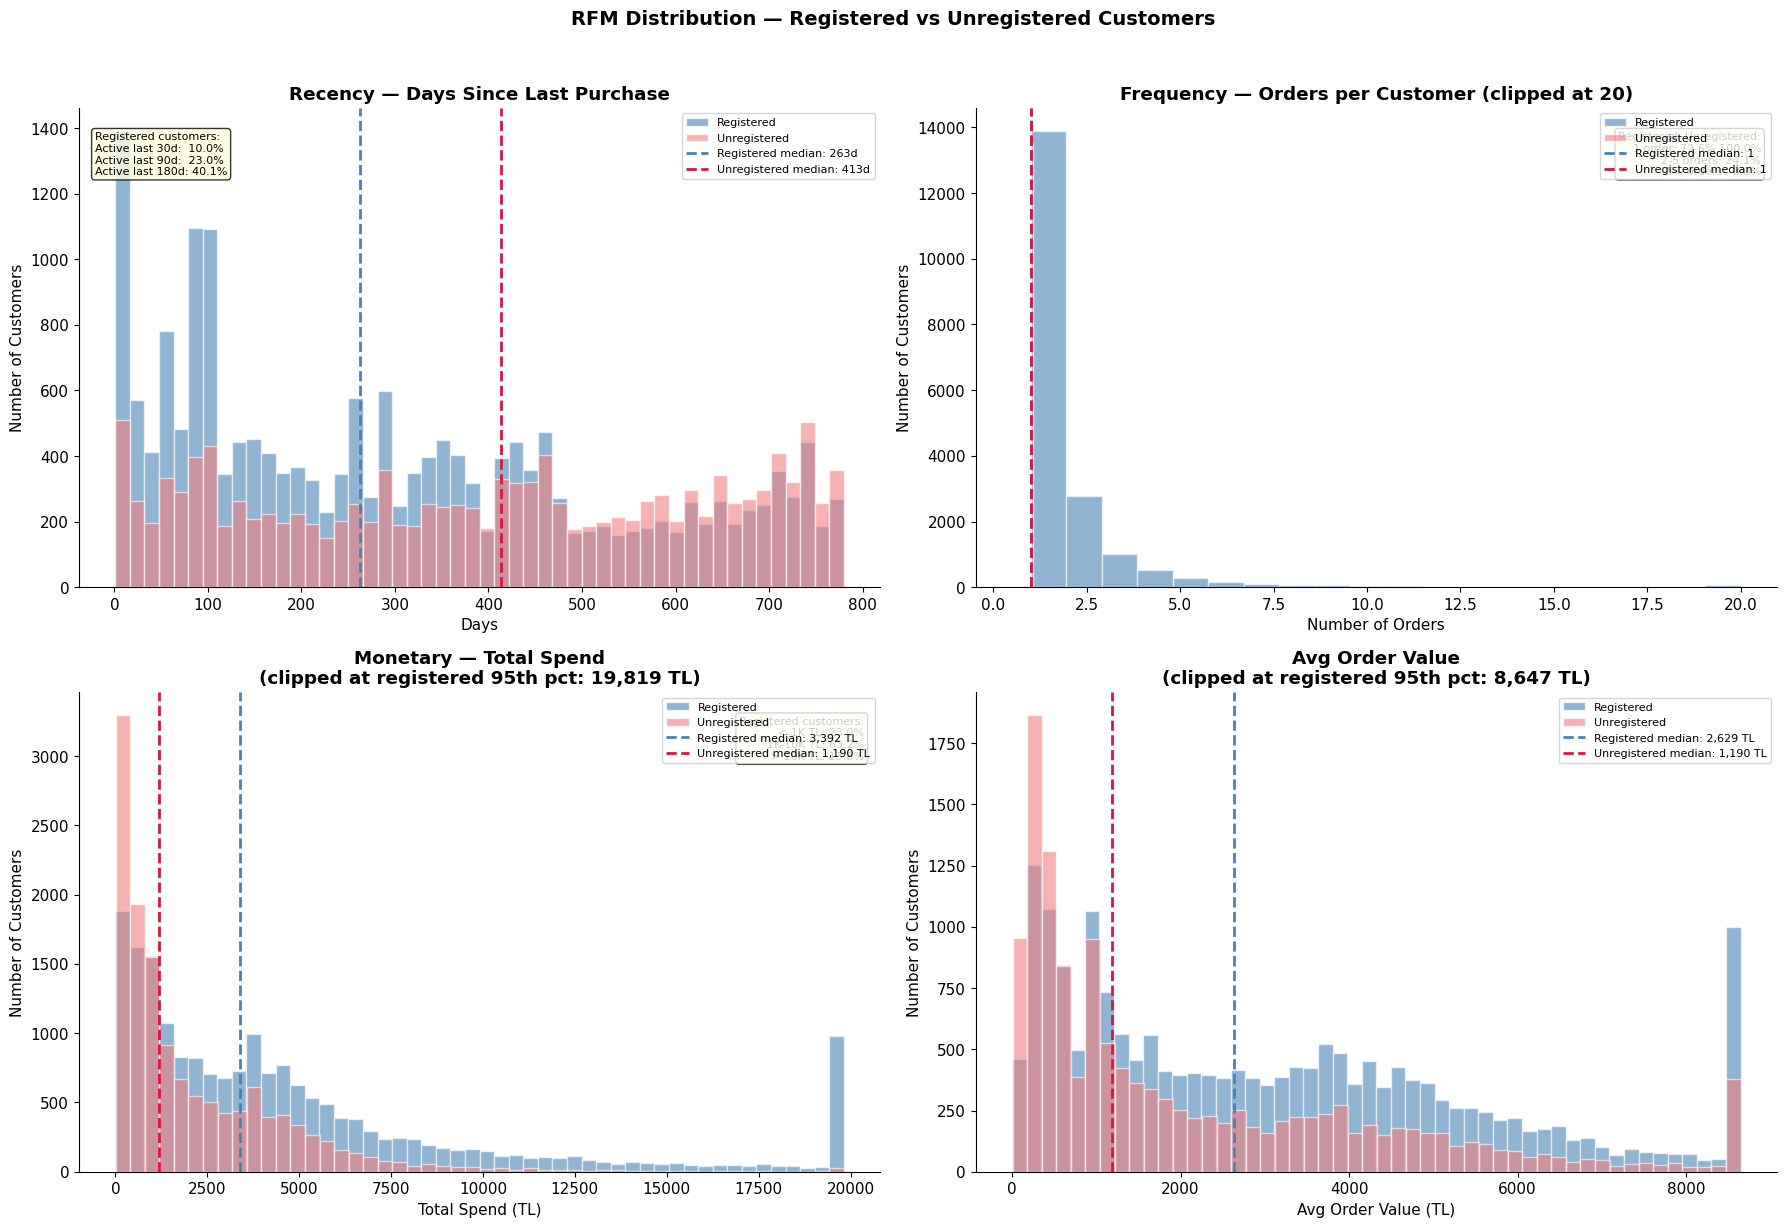

RFM Comparison — Registered vs Unregistered Customers
Metric                         Registered    Unregistered
Total customers                    19,152          13,511
Median recency (d)                    263             413
Median frequency                        1               1
Median spend (TL)                   3,392           1,190
Median AOV (TL)                     2,629           1,190
1-order only %                      72.6%          100.0%


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

colors = {'Registered': 'steelblue', 'Unregistered': 'lightcoral'}

# Recency
for ctype, data, color in [
    ('Registered', rfm_registered, 'steelblue'),
    ('Unregistered', rfm_unregistered, 'lightcoral')
]:
    axes[0,0].hist(data['recency_days'], bins=50, alpha=0.6, 
                   color=color, edgecolor='white', label=ctype)

axes[0,0].axvline(rfm_registered['recency_days'].median(), 
                   color='steelblue', linestyle='--', linewidth=2,
                   label=f'Registered median: {rfm_registered["recency_days"].median():.0f}d')
axes[0,0].axvline(rfm_unregistered['recency_days'].median(), 
                   color='crimson', linestyle='--', linewidth=2,
                   label=f'Unregistered median: {rfm_unregistered["recency_days"].median():.0f}d')
axes[0,0].set_title('Recency — Days Since Last Purchase', fontweight='bold')
axes[0,0].set_xlabel('Days')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].legend(loc='upper right', fontsize=8)

# Annotation bottom left so it doesn't overlap
total_reg = len(rfm_registered)
pct_30 = (rfm_registered['recency_days'] <= 30).sum() / total_reg * 100
pct_90 = (rfm_registered['recency_days'] <= 90).sum() / total_reg * 100
pct_180 = (rfm_registered['recency_days'] <= 180).sum() / total_reg * 100
axes[0,0].text(0.02, 0.95,
    f'Registered customers:\n'
    f'Active last 30d:  {pct_30:.1f}%\n'
    f'Active last 90d:  {pct_90:.1f}%\n'
    f'Active last 180d: {pct_180:.1f}%',
    transform=axes[0,0].transAxes, ha='left', va='top',
    fontsize=8, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Frequency
for ctype, data, color in [
    ('Registered', rfm_registered, 'steelblue'),
    ('Unregistered', rfm_unregistered, 'lightcoral')
]:
    axes[0,1].hist(data['frequency'].clip(upper=20), bins=20, alpha=0.6,
                   color=color, edgecolor='white', label=ctype)

axes[0,1].axvline(rfm_registered['frequency'].median(), 
                   color='steelblue', linestyle='--', linewidth=2,
                   label=f'Registered median: {rfm_registered["frequency"].median():.0f}')
axes[0,1].axvline(rfm_unregistered['frequency'].median(), 
                   color='crimson', linestyle='--', linewidth=2,
                   label=f'Unregistered median: {rfm_unregistered["frequency"].median():.0f}')
axes[0,1].set_title('Frequency — Orders per Customer (clipped at 20)', fontweight='bold')
axes[0,1].set_xlabel('Number of Orders')
axes[0,1].set_ylabel('Number of Customers')
axes[0,1].legend(loc='upper right', fontsize=8)

pct_1_reg = (rfm_registered['frequency'] == 1).sum() / total_reg * 100
pct_2_5_reg = ((rfm_registered['frequency'] >= 2) & (rfm_registered['frequency'] <= 5)).sum() / total_reg * 100
pct_5plus_reg = (rfm_registered['frequency'] > 5).sum() / total_reg * 100
pct_1_unreg = (rfm_unregistered['frequency'] == 1).sum() / len(rfm_unregistered) * 100

axes[0,1].text(0.98, 0.95,
    f'Registered: Unregistered:\n'
    f'1 order: {pct_1_reg:.1f}% {pct_1_unreg:.1f}%\n'
    f'2-5 orders: {pct_2_5_reg:.1f}%\n'
    f'5+ orders:  {pct_5plus_reg:.1f}%',
    transform=axes[0,1].transAxes, ha='right', va='top',
    fontsize=8, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Monetary
monetary_clip = rfm_registered['monetary'].quantile(0.95)
for ctype, data, color in [
    ('Registered', rfm_registered, 'steelblue'),
    ('Unregistered', rfm_unregistered, 'lightcoral')
]:
    axes[1,0].hist(data['monetary'].clip(upper=monetary_clip), bins=50, alpha=0.6,
                   color=color, edgecolor='white', label=ctype)

axes[1,0].axvline(rfm_registered['monetary'].median(), 
                   color='steelblue', linestyle='--', linewidth=2,
                   label=f'Registered median: {rfm_registered["monetary"].median():,.0f} TL')
axes[1,0].axvline(rfm_unregistered['monetary'].median(), 
                   color='crimson', linestyle='--', linewidth=2,
                   label=f'Unregistered median: {rfm_unregistered["monetary"].median():,.0f} TL')
axes[1,0].set_title(f'Monetary — Total Spend\n(clipped at registered 95th pct: {monetary_clip:,.0f} TL)', 
                     fontweight='bold')
axes[1,0].set_xlabel('Total Spend (TL)')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].legend(loc='upper right', fontsize=8)

pct_under1k = (rfm_registered['monetary'] < 1000).sum() / total_reg * 100
pct_1k_10k = ((rfm_registered['monetary'] >= 1000) & (rfm_registered['monetary'] < 10000)).sum() / total_reg * 100
pct_over10k = (rfm_registered['monetary'] >= 10000).sum() / total_reg * 100
axes[1,0].text(0.98, 0.95,
    f'Registered customers:\n'
    f'< 1K TL: {pct_under1k:.1f}%\n'
    f'1K-10K TL: {pct_1k_10k:.1f}%\n'
    f'> 10K TL: {pct_over10k:.1f}%',
    transform=axes[1,0].transAxes, ha='right', va='top',
    fontsize=8, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Avg Order Value
aov_clip = rfm_registered['avg_order_value'].quantile(0.95)
for ctype, data, color in [
    ('Registered', rfm_registered, 'steelblue'),
    ('Unregistered', rfm_unregistered, 'lightcoral')
]:
    axes[1,1].hist(data['avg_order_value'].clip(upper=aov_clip), bins=50, alpha=0.6,
                   color=color, edgecolor='white', label=ctype)

axes[1,1].axvline(rfm_registered['avg_order_value'].median(), 
                   color='steelblue', linestyle='--', linewidth=2,
                   label=f'Registered median: {rfm_registered["avg_order_value"].median():,.0f} TL')
axes[1,1].axvline(rfm_unregistered['avg_order_value'].median(), 
                   color='crimson', linestyle='--', linewidth=2,
                   label=f'Unregistered median: {rfm_unregistered["avg_order_value"].median():,.0f} TL')
axes[1,1].set_title(f'Avg Order Value\n(clipped at registered 95th pct: {aov_clip:,.0f} TL)', 
                     fontweight='bold')
axes[1,1].set_xlabel('Avg Order Value (TL)')
axes[1,1].set_ylabel('Number of Customers')
axes[1,1].legend(loc='upper right', fontsize=8)

plt.suptitle('RFM Distribution — Registered vs Unregistered Customers', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_07_rfm_registered_vs_unregistered.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean summary
print('RFM Comparison — Registered vs Unregistered Customers')
print(f'{"Metric":<25} {"Registered":>15} {"Unregistered":>15}')
metrics = [
    ('Total customers',    f'{total_reg:,}',  
                           f'{len(rfm_unregistered):,}'),
    ('Median recency (d)', f'{rfm_registered["recency_days"].median():.0f}',
                           f'{rfm_unregistered["recency_days"].median():.0f}'),
    ('Median frequency',   f'{rfm_registered["frequency"].median():.0f}',
                           f'{rfm_unregistered["frequency"].median():.0f}'),
    ('Median spend (TL)',  f'{rfm_registered["monetary"].median():,.0f}',
                           f'{rfm_unregistered["monetary"].median():,.0f}'),
    ('Median AOV (TL)',    f'{rfm_registered["avg_order_value"].median():,.0f}',
                           f'{rfm_unregistered["avg_order_value"].median():,.0f}'),
    ('1-order only %',     f'{pct_1_reg:.1f}%',
                           f'{pct_1_unreg:.1f}%'),
]
for label, reg, unreg in metrics:
    print(f'{label:<25} {reg:>15} {unreg:>15}')

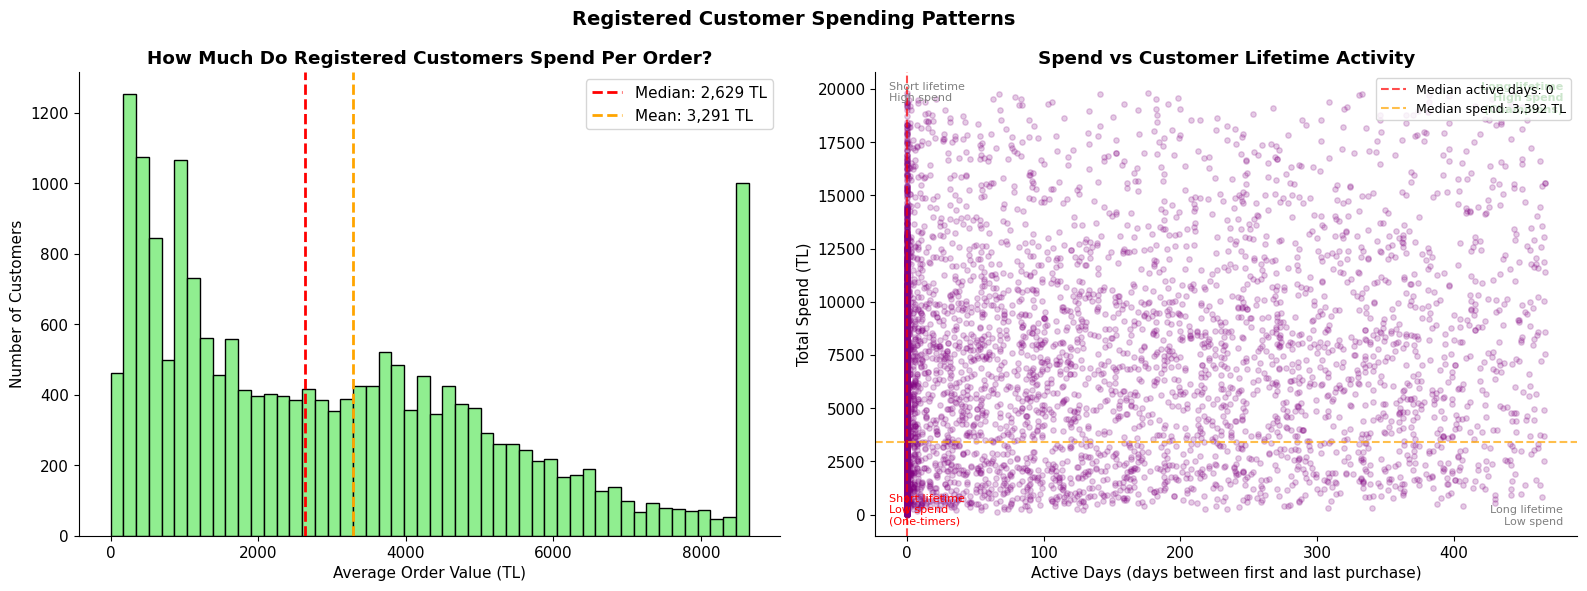

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg Order Value Distribution
aov_clip = rfm_registered['avg_order_value'].quantile(0.95)
axes[0].hist(rfm_registered['avg_order_value'].clip(upper=aov_clip), 
             bins=50, color='lightgreen', edgecolor='black')
axes[0].axvline(rfm_registered['avg_order_value'].median(), color='red',
                linestyle='--', linewidth=2,
                label=f'Median: {rfm_registered["avg_order_value"].median():,.0f} TL')
axes[0].axvline(rfm_registered['avg_order_value'].mean(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Mean: {rfm_registered["avg_order_value"].mean():,.0f} TL')
axes[0].set_xlabel('Average Order Value (TL)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('How Much Do Registered Customers Spend Per Order?', fontweight='bold')
axes[0].legend(loc='upper right')

# Spend vs Active Days Scatter
# active_days = days between first and last purchase
# this is continuous (0-780) so it looks like the reference chart
monetary_clip = rfm_registered['monetary'].quantile(0.95)
active_clip   = rfm_registered['active_days'].quantile(0.95)

scatter_data = rfm_registered[
    (rfm_registered['monetary'] <= monetary_clip) &
    (rfm_registered['active_days'] <= active_clip)
].copy()

axes[1].scatter(scatter_data['active_days'], scatter_data['monetary'],
                alpha=0.2, s=15, color='purple')
axes[1].set_xlabel('Active Days (days between first and last purchase)')
axes[1].set_ylabel('Total Spend (TL)')
axes[1].set_title('Spend vs Customer Lifetime Activity', fontweight='bold')

# Reference lines
med_days  = rfm_registered['active_days'].median()
med_spend = rfm_registered['monetary'].median()
axes[1].axvline(med_days, color='red', linestyle='--', alpha=0.7,
                label=f'Median active days: {med_days:.0f}')
axes[1].axhline(med_spend, color='orange', linestyle='--', alpha=0.7,
                label=f'Median spend: {med_spend:,.0f} TL')
axes[1].legend(loc='upper right', fontsize=9)

# Quadrant labels
axes[1].text(0.02, 0.98, 'Short lifetime\nHigh spend', 
             transform=axes[1].transAxes, va='top', fontsize=8, color='gray')
axes[1].text(0.98, 0.98, 'Long lifetime\nHigh spend\n(Champions)', 
             transform=axes[1].transAxes, va='top', ha='right', fontsize=8, 
             color='green', fontweight='bold')
axes[1].text(0.02, 0.02, 'Short lifetime\nLow spend\n(One-timers)', 
             transform=axes[1].transAxes, va='bottom', fontsize=8, color='red')
axes[1].text(0.98, 0.02, 'Long lifetime\nLow spend', 
             transform=axes[1].transAxes, va='bottom', ha='right', fontsize=8, color='gray')

plt.suptitle('Registered Customer Spending Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07b_spend_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2.2 — Can we segment customers into meaningful groups?
Rather than treating all customers equally, segmentation lets our recommendation model personalize by segment — e.g. high-frequency buyers get different recommendations than one-time buyers.

In [21]:
# RFM Scoring (1-5 scale)
# Using registered customers only
snapshot_date = df['purchase_date'].max() + pd.Timedelta(days=1)

rfm_registered = registered.groupby('customer_id').agg(
    recency_days=('purchase_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('line_total', 'sum'),
    avg_order_value=('line_total', lambda x: x.sum() / registered.loc[x.index, 'order_id'].nunique()),
    first_purchase=('purchase_date', 'min'),
    last_purchase=('purchase_date', 'max')
).reset_index()
rfm_registered['active_days'] = (
    rfm_registered['last_purchase'] - rfm_registered['first_purchase']
).dt.days

# Recency: lower days = better = higher score
rfm_registered['R_score'] = pd.qcut(
    rfm_registered['recency_days'], q=5, labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency & Monetary: higher = better = higher score
# rank(method='first') breaks ties so qcut doesn't fail on duplicate values
rfm_registered['F_score'] = pd.qcut(
    rfm_registered['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_registered['M_score'] = pd.qcut(
    rfm_registered['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_registered['RFM_score'] = (
    rfm_registered['R_score'].astype(str) +
    rfm_registered['F_score'].astype(str) +
    rfm_registered['M_score'].astype(str)
)

print("Score distributions:")
print(f"R_score: {rfm_registered['R_score'].value_counts().sort_index().to_dict()}")
print(f"F_score: {rfm_registered['F_score'].value_counts().sort_index().to_dict()}")
print(f"M_score: {rfm_registered['M_score'].value_counts().sort_index().to_dict()}")

Score distributions:
R_score: {1: 3821, 2: 3840, 3: 3817, 4: 3832, 5: 3842}
F_score: {1: 3831, 2: 3830, 3: 3830, 4: 3830, 5: 3831}
M_score: {1: 3831, 2: 3830, 3: 3830, 4: 3830, 5: 3831}


In [23]:
# Segment Assignment
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    # Tier 1: Best customers — recent, frequent, high spenders
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Tier 2: Were your best customers but have gone quiet
    # MUST come before Loyal Customers — otherwise f>=4, m>=4 absorbs them
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"

    # Tier 3: Loyal and still relatively active (r >= 3 ensures they are not lapsed)
    elif r >= 3 and f >= 4 and m >= 4:
        return 'Loyal Customers'

    # Tier 4: Recent buyers showing loyalty signals — nurture them
    elif r >= 4 and (f >= 3 or m >= 3):
        return 'Potential Loyalists'

    # Tier 5: Brand new — recent but low history
    elif r >= 4 and f <= 2 and m <= 2:
        return 'New Customers'

    # Tier 6: Used to buy regularly, now slipping — still some recency
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'

    # Tier 7: Gone quiet and were never high-value — likely lost
    elif r <= 2 and f <= 2:
        return 'Hibernating'

    # Tier 8: Still active but spending is low — price-driven buyers
    elif r >= 3 and f >= 3 and m <= 2:
        return 'Price Sensitive'

    # Tier 9: Middle of the road — decent recency and frequency, watch closely
    elif r == 3 and f >= 3:
        return 'Need Attention'

    # Catch-all for any remaining combinations
    else:
        return 'Others'


rfm_registered['segment'] = rfm_registered.apply(assign_segment, axis=1)

In [26]:
# Segment Summary
segment_summary = rfm_registered.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).sort_values('customer_count', ascending=False)

segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100
).round(1)
segment_summary['customer_pct'] = (
    segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100
).round(1)

print("Customer Segments Summary (Kagan Parfumary):")
print(segment_summary[[
    'customer_count', 'customer_pct', 'revenue_pct',
    'avg_recency', 'avg_frequency', 'avg_monetary', 'avg_order_value'
]].to_string())

Customer Segments Summary (Kagan Parfumary):
                     customer_count  customer_pct  revenue_pct  avg_recency  avg_frequency  avg_monetary  avg_order_value
segment                                                                                                                  
Hibernating                    6252         32.60        11.40       555.72           1.00       2415.61          2415.61
Potential Loyalists            4183         21.80        10.20        89.47           1.19       3219.23          3046.25
Champions                      3341         17.40        55.30        61.56           4.92      21834.56          5486.81
Others                         1373          7.20         2.60       378.35           1.32       2506.66          2324.25
Need Attention                 1108          5.80         4.40       249.52           1.19       5273.45          5045.11
Price Sensitive                1025          5.40         0.80       245.53           1.20       1036

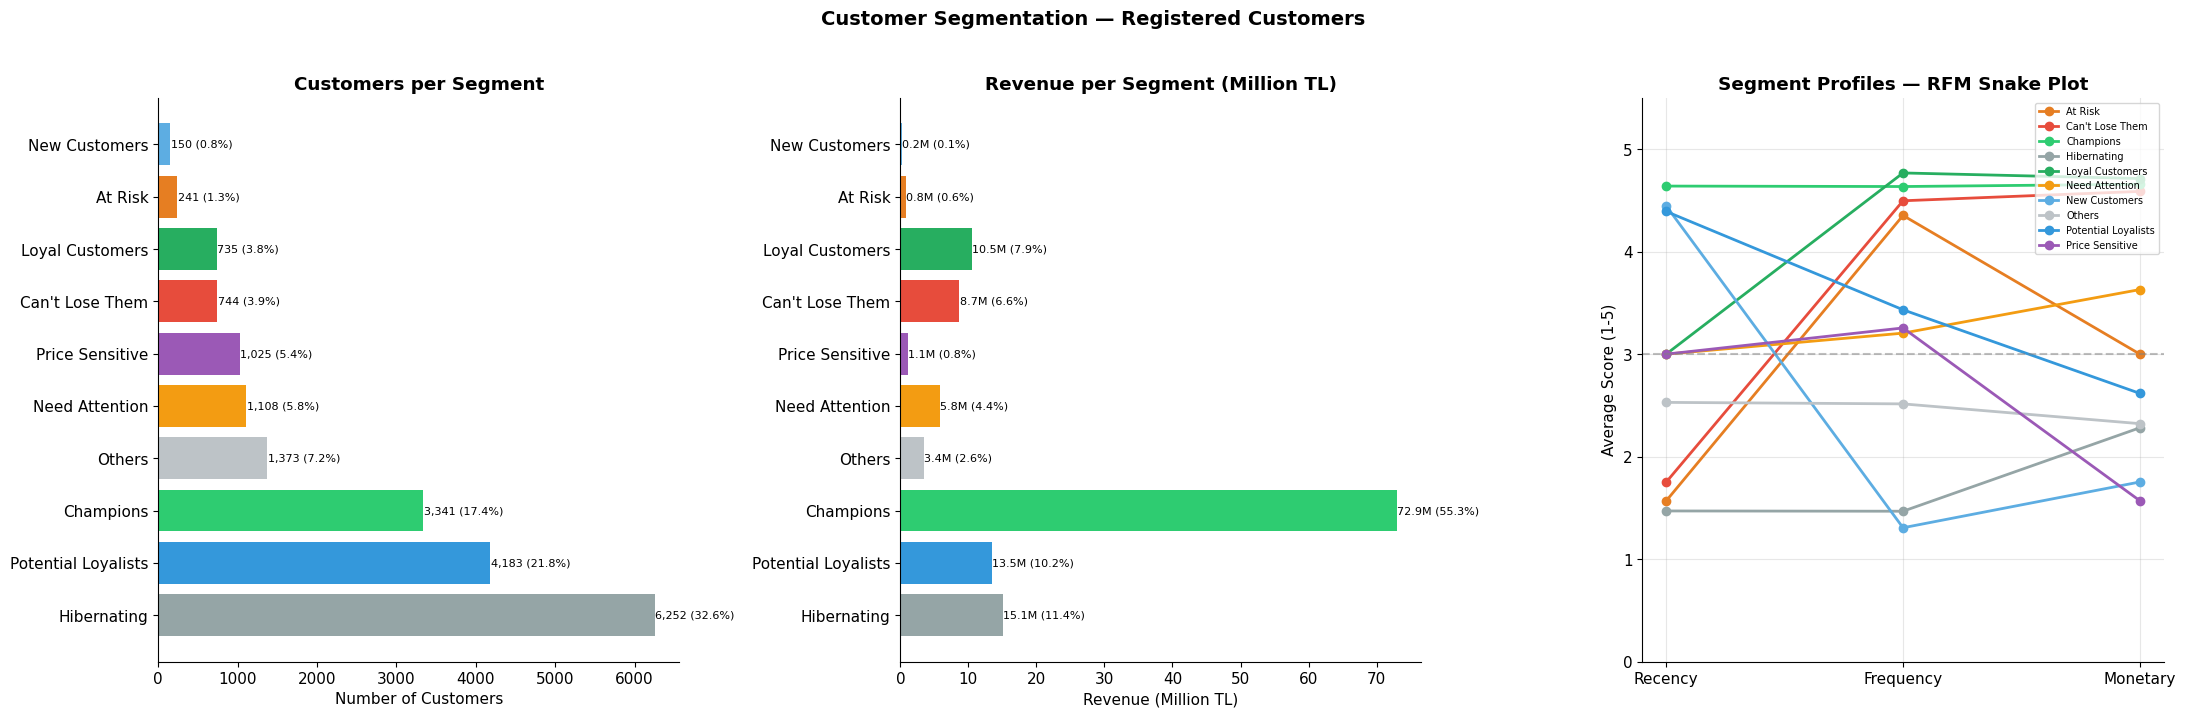

In [27]:
# Visualize Segments
segment_colors = {
    'Champions':          '#2ecc71',
    'Loyal Customers':    '#27ae60',
    'Potential Loyalists':'#3498db',
    'New Customers':      '#5dade2',
    "Can't Lose Them":    '#e74c3c',
    'At Risk':            '#e67e22',
    'Hibernating':        '#95a5a6',
    'Need Attention':     '#f39c12',
    'Price Sensitive':    '#9b59b6',
    'Others':             '#bdc3c7'
}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

seg_order = segment_summary.index.tolist()
colors = [segment_colors.get(s, '#bdc3c7') for s in seg_order]

# Customer count
bars = axes[0].barh(seg_order, segment_summary['customer_count'], color=colors)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
for bar, (pct, cnt) in zip(bars, zip(segment_summary['customer_pct'], 
                                      segment_summary['customer_count'])):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=8)

# Revenue share
bars2 = axes[1].barh(seg_order, segment_summary['total_revenue'] / 1e6, color=colors)
axes[1].set_title('Revenue per Segment (Million TL)', fontweight='bold')
axes[1].set_xlabel('Revenue (Million TL)')
for bar, (pct, rev) in zip(bars2, zip(segment_summary['revenue_pct'],
                                       segment_summary['total_revenue'])):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{rev/1e6:.1f}M ({pct:.1f}%)', va='center', fontsize=8)

# RFM Snake plot — avg scores per segment on a 1-5 scale
# Snake plot shows the profile of each segment across R, F, M dimensions
snake_data = rfm_registered.groupby('segment')[['R_score', 'F_score', 'M_score']].mean()
for segment in snake_data.index:
    color = segment_colors.get(segment, '#bdc3c7')
    axes[2].plot(['Recency', 'Frequency', 'Monetary'], 
                 snake_data.loc[segment], 
                 marker='o', linewidth=2, label=segment, color=color)

axes[2].set_title('Segment Profiles — RFM Snake Plot', fontweight='bold')
axes[2].set_ylabel('Average Score (1-5)')
axes[2].set_ylim(0, 5.5)
axes[2].legend(fontsize=7, loc='upper right')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(3, color='gray', linestyle='--', alpha=0.5, label='Midpoint')

plt.suptitle('Customer Segmentation — Registered Customers', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_08_customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2.3 — What do different customer segments buy?
This directly informs personalized recommendations — Champions might need luxury upsells, while New Customers might need category exploration nudges.

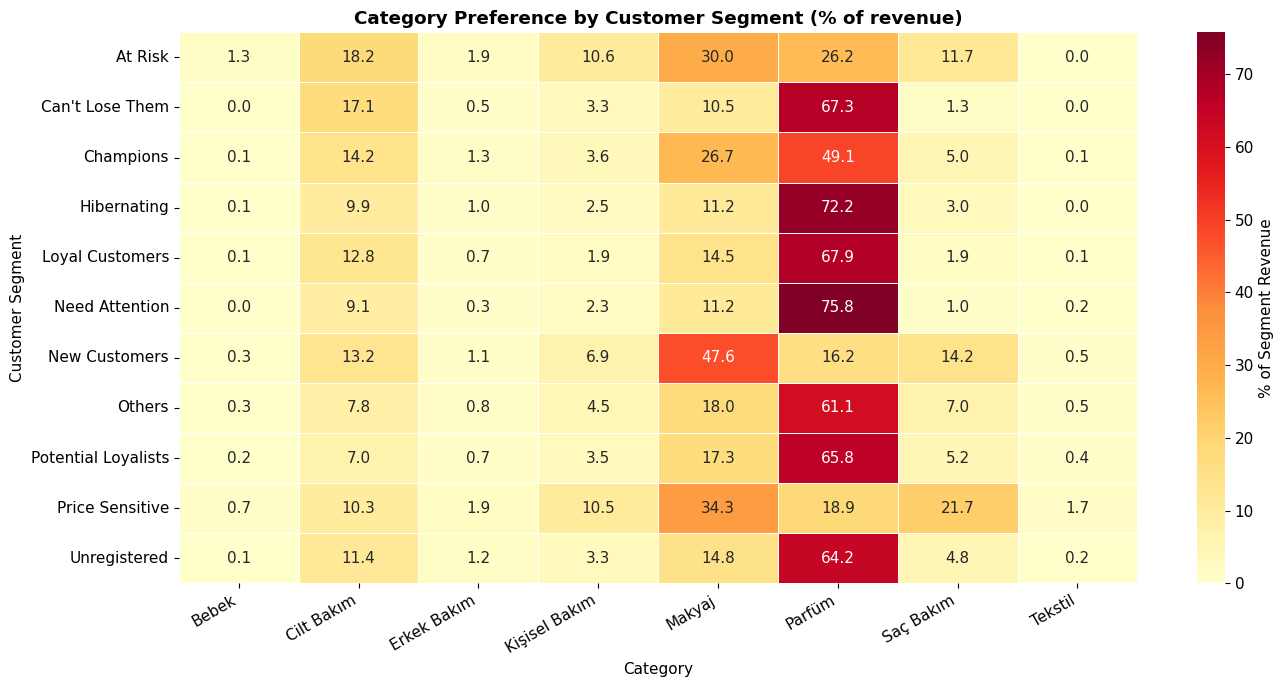

In [30]:
# Merge segment back to transactions
df = df.merge(rfm_registered[['customer_id', 'segment', 'RFM_score']], on='customer_id', how='left')
# Unregistered customers won't have a segment — label them explicitly
df['segment'] = df['segment'].fillna('Unregistered')

# Category preferences by segment
seg_category = (
    df.groupby(['segment', 'category_main'])['line_total']
    .sum()
    .reset_index()
)

# Normalize to % within each segment
seg_totals = seg_category.groupby('segment')['line_total'].transform('sum')
seg_category['pct'] = seg_category['line_total'] / seg_totals * 100

seg_pivot = seg_category.pivot(index='segment', columns='category_main', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(seg_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% of Segment Revenue'})
ax.set_title('Category Preference by Customer Segment (% of revenue)', fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Customer Segment')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_09_segment_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

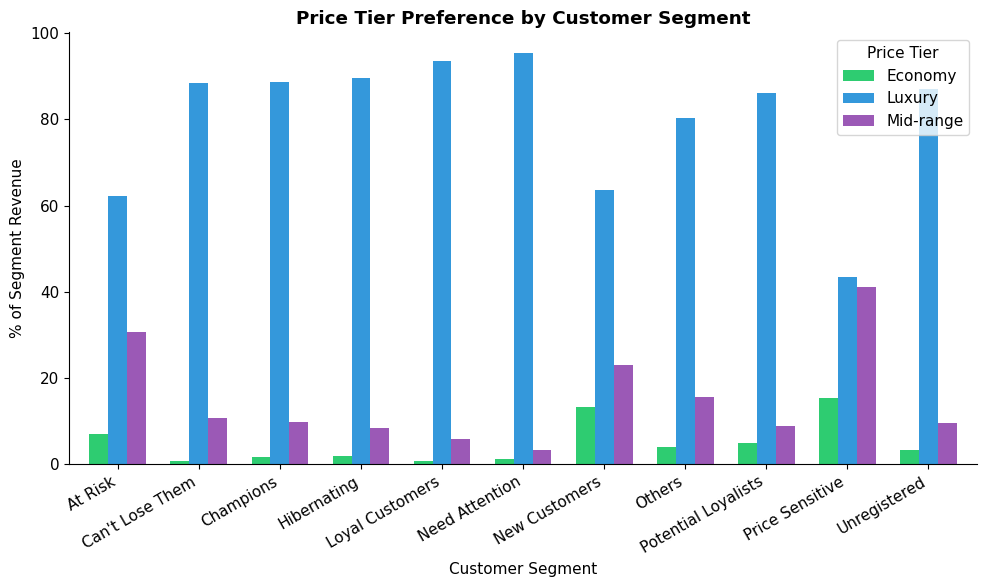

In [31]:
# Price tier preference by segment
seg_tier = (
    df.groupby(['segment', 'price_tier'])['line_total']
    .sum()
    .reset_index()
)
seg_tier_totals = seg_tier.groupby('segment')['line_total'].transform('sum')
seg_tier['pct'] = seg_tier['line_total'] / seg_tier_totals * 100

tier_pivot = seg_tier.pivot(index='segment', columns='price_tier', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
tier_pivot.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#9b59b6'], width=0.7)
ax.set_title('Price Tier Preference by Customer Segment', fontweight='bold')
ax.set_ylabel('% of Segment Revenue')
ax.set_xlabel('Customer Segment')
plt.xticks(rotation=30, ha='right')
ax.legend(title='Price Tier')
plt.tight_layout()
plt.savefig('fig_10_segment_tier.png', dpi=150, bbox_inches='tight')
plt.show()

### Q2.4 — What are purchase patterns over time?
Seasonality in beauty retail is strong — identifying peak months helps us understand when recommendation nudges have the most impact.

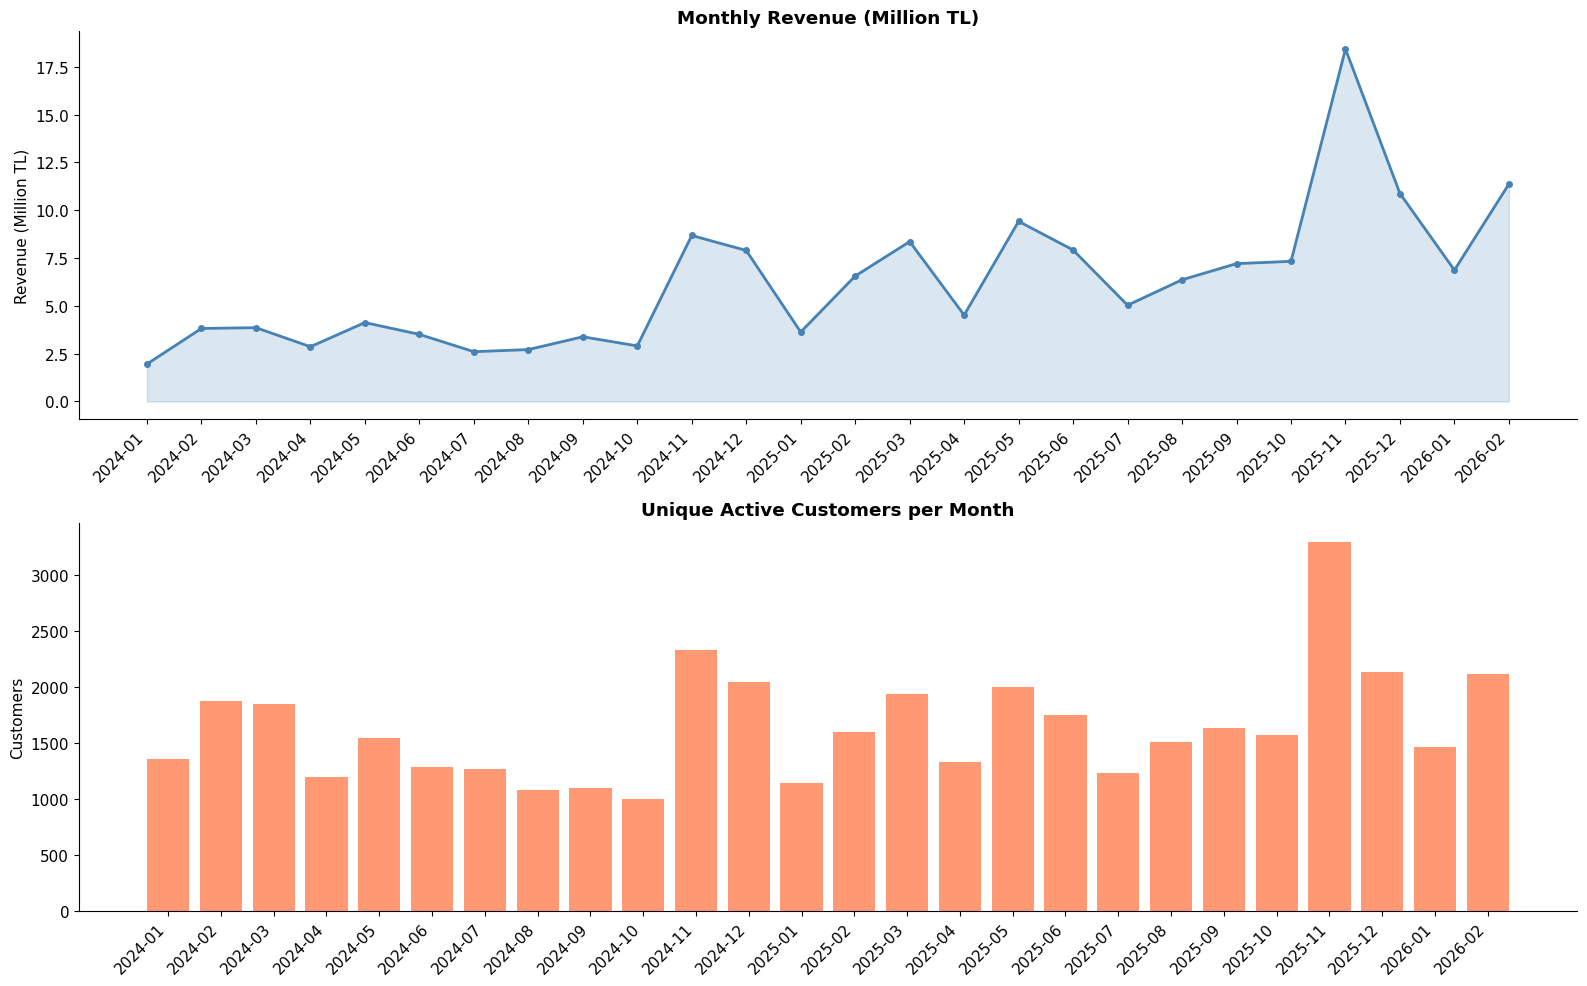

In [32]:
# Monthly revenue and order trends
df['year_month'] = df['purchase_date'].dt.to_period('M')
monthly = df.groupby('year_month').agg(
    revenue=('line_total', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique')
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Revenue over time
axes[0].plot(monthly['year_month_str'], monthly['revenue'] / 1e6, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(monthly['year_month_str'], monthly['revenue'] / 1e6, alpha=0.2, color='steelblue')
axes[0].set_title('Monthly Revenue (Million TL)', fontweight='bold')
axes[0].set_ylabel('Revenue (Million TL)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Unique customers per month
axes[1].bar(monthly['year_month_str'], monthly['customers'], color='coral', alpha=0.8)
axes[1].set_title('Unique Active Customers per Month', fontweight='bold')
axes[1].set_ylabel('Customers')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('fig_11_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

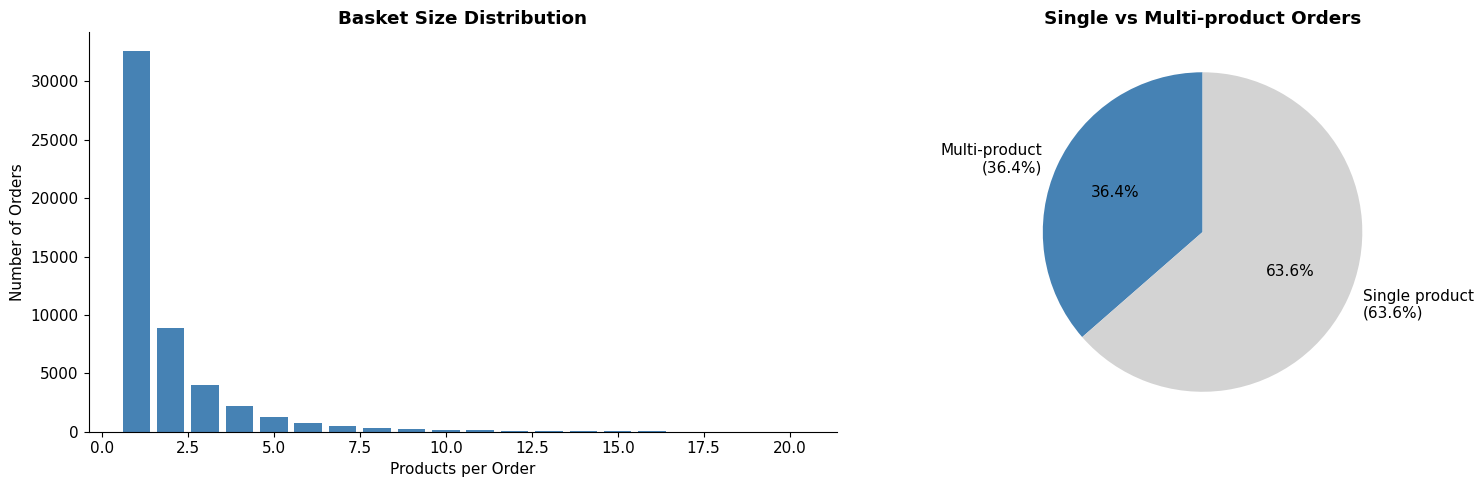

Average basket size: 1.91 products per order
Median basket size: 1 products per order
Orders with >1 product: 36.4% — these are our co-purchase signal source


In [33]:
# Basket size distribution — how many products per order?
basket_size = df.groupby('order_id')['product_code'].count().reset_index()
basket_size.columns = ['order_id', 'basket_size']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution
basket_counts = basket_size['basket_size'].value_counts().sort_index().head(20)
axes[0].bar(basket_counts.index, basket_counts.values, color='steelblue')
axes[0].set_xlabel('Products per Order')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Basket Size Distribution', fontweight='bold')

# Cumulative — what % of orders have > 1 product?
basket_size['multi_item'] = basket_size['basket_size'] > 1
multi_pct = basket_size['multi_item'].mean() * 100

axes[1].pie(
    [multi_pct, 100 - multi_pct],
    labels=[f'Multi-product\n({multi_pct:.1f}%)', f'Single product\n({100-multi_pct:.1f}%)'],
    colors=['steelblue', 'lightgray'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Single vs Multi-product Orders', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_12_basket_size.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Average basket size: {basket_size["basket_size"].mean():.2f} products per order')
print(f'Median basket size: {basket_size["basket_size"].median():.0f} products per order')
print(f'Orders with >1 product: {multi_pct:.1f}% — these are our co-purchase signal source')

---
## Section 3: Co-purchase & Complementary Product Analysis

### Q3.1 — Which products are bought together most often?
This is the core signal for our complementary product recommendation. Products frequently bought together in the same order are strong candidates for "customers also bought" suggestions.

In [34]:
# Build co-purchase pairs from multi-item orders
# For each order with >1 product, generate all product pairs
multi_item_orders = df.groupby('order_id')['product_code'].apply(list)
multi_item_orders = multi_item_orders[multi_item_orders.apply(len) > 1]

print(f'Multi-item orders: {len(multi_item_orders):,}')
print('Generating co-purchase pairs...')

pair_counts = Counter()
for products_in_order in multi_item_orders:
    unique_products = list(set(products_in_order))  # deduplicate within order
    for pair in combinations(sorted(unique_products), 2):
        pair_counts[pair] += 1

# Convert to DataFrame
copurchase_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in pair_counts.items()],
    columns=['product_a', 'product_b', 'co_purchase_count']
).sort_values('co_purchase_count', ascending=False)

print(f'Total unique product pairs: {len(copurchase_df):,}')
print(f'\nTop 20 most co-purchased pairs:')

# Add product names
product_names = df[['product_code', 'product_name']].drop_duplicates('product_code').set_index('product_code')['product_name']
copurchase_df['name_a'] = copurchase_df['product_a'].map(product_names)
copurchase_df['name_b'] = copurchase_df['product_b'].map(product_names)

print(copurchase_df[['name_a', 'name_b', 'co_purchase_count']].head(20).to_string(index=False))

Multi-item orders: 18,654
Generating co-purchase pairs...
Total unique product pairs: 117,140

Top 20 most co-purchased pairs:
                                                                       name_a                                                                            name_b  co_purchase_count
                            John Frieda Yoğun Hacim Kazandıran Şampuan 250 Ml     John Frieda Kahverengi Saçlara Özel Renk Koruyucu Nemlendirici Şampuan 250 Ml                 70
                                                   Lancome Hypnose Mascara 01                                                        Lancome Hypnose Mascara 02                 64
                    John Frieda Şampuan Sarı Saçlara Özel Işıltı Veren 250 Ml     John Frieda Kahverengi Saçlara Özel Renk Koruyucu Nemlendirici Şampuan 250 Ml                 60
                                 Arko Nem Soft Touch Krem 250 Ml + 250 Ml Set                              Arko Nem Extra Nemlendirici Krem 250 Ml + 250 Ml S

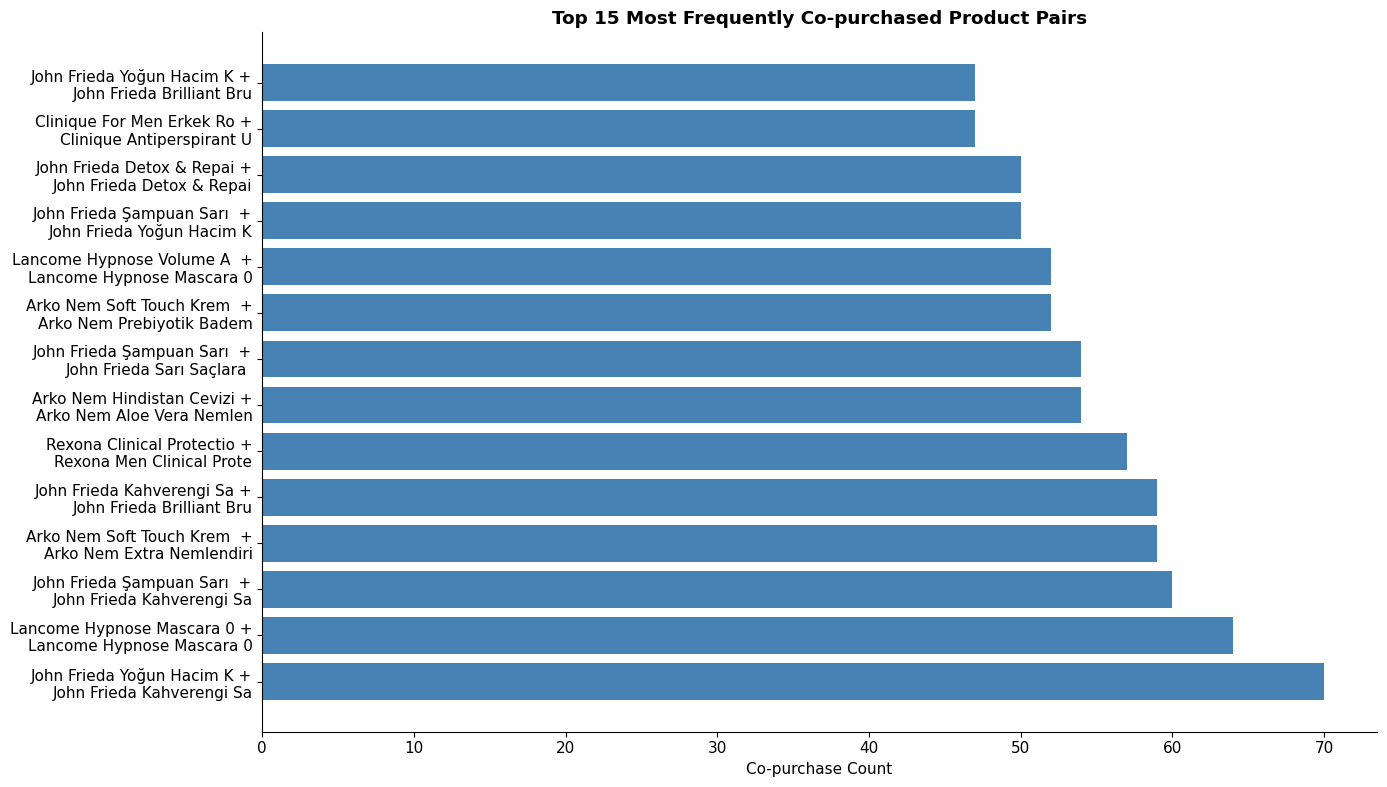

In [35]:
# Visualize top co-purchase pairs
top_pairs = copurchase_df.head(15).copy()
top_pairs['pair_label'] = (
    top_pairs['name_a'].str[:25] + ' +\n' + top_pairs['name_b'].str[:25]
)

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(top_pairs['pair_label'], top_pairs['co_purchase_count'], color='steelblue')
ax.set_xlabel('Co-purchase Count')
ax.set_title('Top 15 Most Frequently Co-purchased Product Pairs', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_copurchase_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

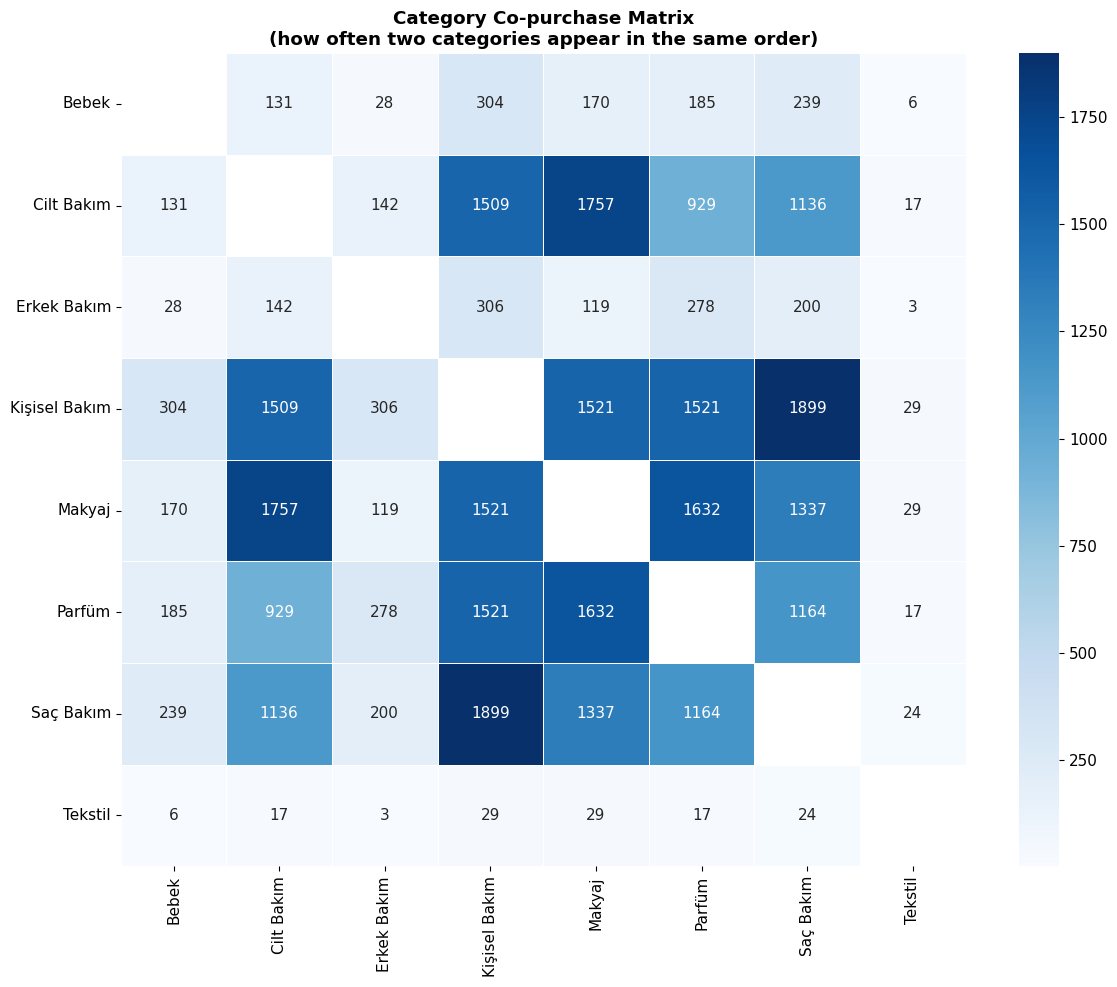

Orders with missing category dropped: 1,342
Categories in matrix: ['Bebek', 'Cilt Bakım', 'Erkek Bakım', 'Kişisel Bakım', 'Makyaj', 'Parfüm', 'Saç Bakım', 'Tekstil']

Top category pairs bought together:
        cat_a         cat_b  count
Kişisel Bakım     Saç Bakım   1899
   Cilt Bakım        Makyaj   1757
       Makyaj        Parfüm   1632
Kişisel Bakım        Parfüm   1521
Kişisel Bakım        Makyaj   1521
   Cilt Bakım Kişisel Bakım   1509
       Makyaj     Saç Bakım   1337
       Parfüm     Saç Bakım   1164
   Cilt Bakım     Saç Bakım   1136
   Cilt Bakım        Parfüm    929


In [36]:
# Drop rows with missing category_main before analysis
order_categories = (
    df.dropna(subset=['category_main'])
    .groupby('order_id')['category_main']
    .apply(list)
)
order_categories = order_categories[order_categories.apply(len) > 1]

cat_pair_counts = Counter()
for cats in order_categories:
    unique_cats = list(set(cats))
    if len(unique_cats) > 1:
        for pair in combinations(sorted(unique_cats), 2):
            cat_pair_counts[pair] += 1

cat_pair_df = pd.DataFrame(
    [(a, b, count) for (a, b), count in cat_pair_counts.items()],
    columns=['cat_a', 'cat_b', 'count']
).sort_values('count', ascending=False)

# Build symmetric matrix — only non-null categories
all_cats = sorted(df['category_main'].dropna().unique())
all_cats = [c for c in all_cats if str(c).strip() != '']  # also remove empty strings
cat_matrix = pd.DataFrame(0, index=all_cats, columns=all_cats)

for _, row in cat_pair_df.iterrows():
    if row['cat_a'] in all_cats and row['cat_b'] in all_cats:
        cat_matrix.loc[row['cat_a'], row['cat_b']] = row['count']
        cat_matrix.loc[row['cat_b'], row['cat_a']] = row['count']

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(all_cats), dtype=bool)
sns.heatmap(cat_matrix, annot=True, fmt='d', cmap='Blues', ax=ax,
            mask=mask, linewidths=0.5)
ax.set_title('Category Co-purchase Matrix\n(how often two categories appear in the same order)', 
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_category_copurchase.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Orders with missing category dropped: {df["category_main"].isna().sum():,}')
print(f'Categories in matrix: {all_cats}')
print()
print('Top category pairs bought together:')
print(cat_pair_df.head(10).to_string(index=False))

### Q3.2 — Do customers tend to stay within one brand or mix brands?
Brand loyalty vs. brand mixing tells us whether our recommender should prioritize same-brand suggestions or cross-brand complementary products.

[None, None, None, None, None, None, None, None, None, None, None, None]

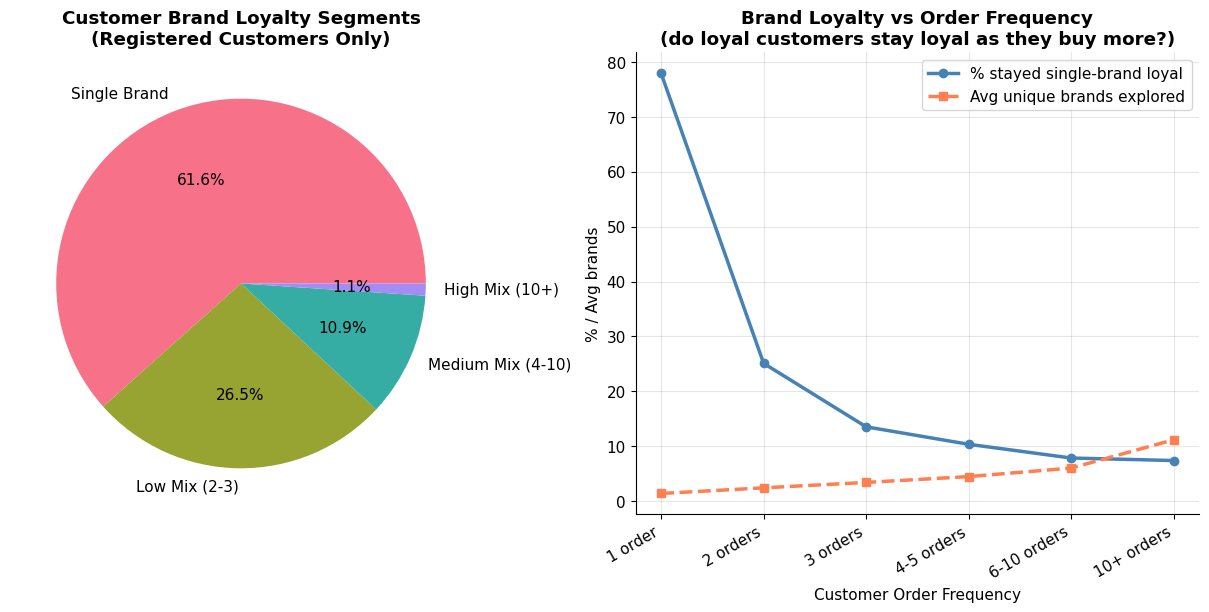

In [37]:
# Brand diversity per customer — registered only
brand_diversity = (
    df[df['segment'] != 'Unregistered']
    .groupby('customer_id').agg(
        unique_brands=('brand', 'nunique'),
        total_orders=('order_id', 'nunique')
    ).reset_index()
)

brand_diversity['brands_per_order'] = (
    brand_diversity['unique_brands'] / brand_diversity['total_orders']
)

brand_diversity['brand_loyalty'] = pd.cut(
    brand_diversity['unique_brands'],
    bins=[0, 1, 3, 10, float('inf')],
    labels=['Single Brand', 'Low Mix (2-3)', 'Medium Mix (4-10)', 'High Mix (10+)']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Brand loyalty pie (registered only) — what % of customers are single-brand vs multi-brand?
loyalty_counts = brand_diversity['brand_loyalty'].value_counts()
axes[0].pie(loyalty_counts.values, labels=loyalty_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('husl', 4))
axes[0].set_title('Customer Brand Loyalty Segments\n(Registered Customers Only)', 
                   fontweight='bold')

# Right: % of customers who are single-brand by order frequency
# This answers: "among customers who ordered X times, what % stayed with 1 brand?"
order_buckets = pd.cut(
    brand_diversity['total_orders'],
    bins=[0, 1, 2, 3, 5, 10, float('inf')],
    labels=['1 order', '2 orders', '3 orders', '4-5 orders', '6-10 orders', '10+ orders']
)
brand_diversity['order_bucket'] = order_buckets

bucket_loyalty = brand_diversity.groupby('order_bucket', observed=True).apply(
    lambda x: pd.Series({
        'single_brand_pct': (x['unique_brands'] == 1).mean() * 100,
        'multi_brand_pct':  (x['unique_brands'] > 1).mean() * 100,
        'avg_brands':        x['unique_brands'].mean(),
        'customer_count':    len(x)
    })
).reset_index()

axes[1].plot(bucket_loyalty['order_bucket'], bucket_loyalty['single_brand_pct'],
             marker='o', linewidth=2.5, color='steelblue', 
             label='% stayed single-brand loyal')
axes[1].plot(bucket_loyalty['order_bucket'], bucket_loyalty['avg_brands'],
             marker='s', linewidth=2.5, color='coral', linestyle='--',
             label='Avg unique brands explored')

axes[1].set_ylabel('% / Avg brands')
axes[1].set_xlabel('Customer Order Frequency')
axes[1].set_title('Brand Loyalty vs Order Frequency\n(do loyal customers stay loyal as they buy more?)', 
                   fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

---
## Section 4: Feature Importance with Random Forest

### Q4.1 — Which features best predict whether a customer will make a repeat purchase?
We use Random Forest feature importance to understand which engineered features carry the most signal. This directly informs which features to include in our recommendation model.

In [38]:
# Columns to keep and how to process them for modeling

# These don't need to be modified (already numeric)
numeric_cols = [
    'line_total',              # transaction value
    'discount_pct',            # how much discount was applied
    'total_orders',            # customer order count
    'total_products_bought',   # customer product count
    'total_spend_tl',          # customer total spend
    'est_returns',             # estimated returns
    'avg_consumption_days',    # consumption signal
]

# These are bool — convert to int (0/1)
bool_cols = [
    'is_gift',
    'is_subproduct',
    'ever_purchased',
    'has_returned',
    'missing_product_info',
    'price_anomaly',
]

# These are categorical — need One Hot Encoding
# We use OHE here (not Label Encoding) because these are nominal categories
# meaning there's no natural order between them
# e.g. 'Parfüm' is not greater or lesser than 'Makyaj'
ohe_cols = [
    'category_main', # 8 categories → 8 binary columns
    'consumption_bucket', # monthly/quarterly/biannual/annual_plus
    'price_tier', # Economy/Mid-range/Luxury
    'tenure_bucket', # pre_system/less_than_1yr/etc
    'segment', # Champions/Loyal/etc
]

# Dropped columns and why:
drop_cols = {
    'customer_id': 'identifier',
    'order_id': 'identifier',
    'product_code': 'identifier',
    'product_name': 'free text',
    'brand': 'redundant — price_tier captures positioning',
    'category_mid': 'redundant — category_main + category_sub sufficient',
    'category_sub': 'too granular — hundreds of unique values',
    'full_path': 'redundant — covered by category_main + price_tier',
    'quantity': 'redundant — line_total captures this',
    'unit_price': 'redundant — line_total captures this',
    'price_original': 'redundant — have discount_pct',
    'price_discounted': 'redundant — have discount_pct',
    'purchase_date': 'transaction date, not a customer feature',
    'year_month': 'redundant with purchase_date',
    'is_member': 'redundant — segment covers registered/unregistered',
    'is_registered': 'redundant — segment covers this',
    'RFM_score': 'string version of R/F/M scores, redundant',
    'total_products_bought':'redundant with total_orders',
}

In [39]:
# Build the feature matrix for modeling
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Fill NaNs before any conversion
df_rf = df.copy()

# Fill NaN in categorical columns with 'Setler'
# so they become a valid category instead of breaking OHE
for col in ['category_main']:
    if col in df_rf.columns:
        df_rf[col] = df_rf[col].fillna('Setler')

for col in ['tenure_bucket']:
    if col in df_rf.columns:
        df_rf[col] = df_rf[col].fillna('Not_member')

# Fill NaN in bool columns with False before converting to int
for col in bool_cols:
    if col in df_rf.columns:
        df_rf[col] = df_rf[col].fillna(False).astype(int)

# Fill NaN in numeric columns with 0
for col in numeric_cols:
    if col in df_rf.columns:
        df_rf[col] = df_rf[col].fillna(0)

print("NaN counts after filling:")
print(df_rf[numeric_cols + bool_cols + ohe_cols].isnull().sum())

NaN counts after filling:
line_total               0
discount_pct             0
total_orders             0
total_products_bought    0
total_spend_tl           0
est_returns              0
avg_consumption_days     0
is_gift                  0
is_subproduct            0
ever_purchased           0
has_returned             0
missing_product_info     0
price_anomaly            0
category_main            0
consumption_bucket       0
price_tier               0
tenure_bucket            0
segment                  0
dtype: int64


In [40]:
# OHE on categorical columns — this will create new binary columns for each category level
ohe_dummies = pd.get_dummies(
    df_rf[[c for c in ohe_cols if c in df_rf.columns]],
    drop_first=False,
    dummy_na=False
)

print(f"\nOHE produced {ohe_dummies.shape[1]} binary columns:")
print(ohe_dummies.columns.tolist())


OHE produced 31 binary columns:
['category_main_Bebek', 'category_main_Cilt Bakım', 'category_main_Erkek Bakım', 'category_main_Kişisel Bakım', 'category_main_Makyaj', 'category_main_Parfüm', 'category_main_Saç Bakım', 'category_main_Setler', 'category_main_Tekstil', 'consumption_bucket_biannual', 'consumption_bucket_monthly', 'consumption_bucket_quarterly', 'price_tier_Economy', 'price_tier_Luxury', 'price_tier_Mid-range', 'tenure_bucket_1_to_2yr', 'tenure_bucket_2_to_3yr', 'tenure_bucket_<1', 'tenure_bucket_>3yr', 'tenure_bucket_Not_member', 'segment_At Risk', "segment_Can't Lose Them", 'segment_Champions', 'segment_Hibernating', 'segment_Loyal Customers', 'segment_Need Attention', 'segment_New Customers', 'segment_Others', 'segment_Potential Loyalists', 'segment_Price Sensitive', 'segment_Unregistered']


In [41]:
# Build feature matrix by concatenating numeric, bool, and OHE columns
feature_matrix = pd.concat([
    df_rf[numeric_cols].fillna(0),
    df_rf[[c for c in bool_cols if c in df_rf.columns]].fillna(0),
    ohe_dummies.fillna(0)
], axis=1)

# Registered customers only
# Unregistered are always 1-time buyers by definition
# Including them would make the model trivially predict "not repeat" 
# for 41% of data without learning anything meaningful
registered_mask = df_rf['is_registered'] == True
feature_matrix  = feature_matrix[registered_mask].reset_index(drop=True)
y = (df_rf[registered_mask]['total_orders'] > 1).astype(int).reset_index(drop=True)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"\nTarget distribution (registered customers only):")
print(f"Repeat buyers: {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"One-time buyers: {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"\nFeatures: {feature_matrix.columns.tolist()}")

Feature matrix shape: (76533, 44)

Target distribution (registered customers only):
Repeat buyers: 53,434 (69.8%)
One-time buyers: 23,099 (30.2%)

Features: ['line_total', 'discount_pct', 'total_orders', 'total_products_bought', 'total_spend_tl', 'est_returns', 'avg_consumption_days', 'is_gift', 'is_subproduct', 'ever_purchased', 'has_returned', 'missing_product_info', 'price_anomaly', 'category_main_Bebek', 'category_main_Cilt Bakım', 'category_main_Erkek Bakım', 'category_main_Kişisel Bakım', 'category_main_Makyaj', 'category_main_Parfüm', 'category_main_Saç Bakım', 'category_main_Setler', 'category_main_Tekstil', 'consumption_bucket_biannual', 'consumption_bucket_monthly', 'consumption_bucket_quarterly', 'price_tier_Economy', 'price_tier_Luxury', 'price_tier_Mid-range', 'tenure_bucket_1_to_2yr', 'tenure_bucket_2_to_3yr', 'tenure_bucket_<1', 'tenure_bucket_>3yr', 'tenure_bucket_Not_member', 'segment_At Risk', "segment_Can't Lose Them", 'segment_Champions', 'segment_Hibernating', 'seg

In [42]:
# Train Random Forest to predict repeat buyers among registered customers
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print('Model Performance (Registered Customers Only):')
print(classification_report(y_test, rf.predict(X_test)))

Model Performance (Registered Customers Only):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4620
           1       1.00      1.00      1.00     10687

    accuracy                           1.00     15307
   macro avg       1.00      1.00      1.00     15307
weighted avg       1.00      1.00      1.00     15307



^ Data Leakage for Random Forest

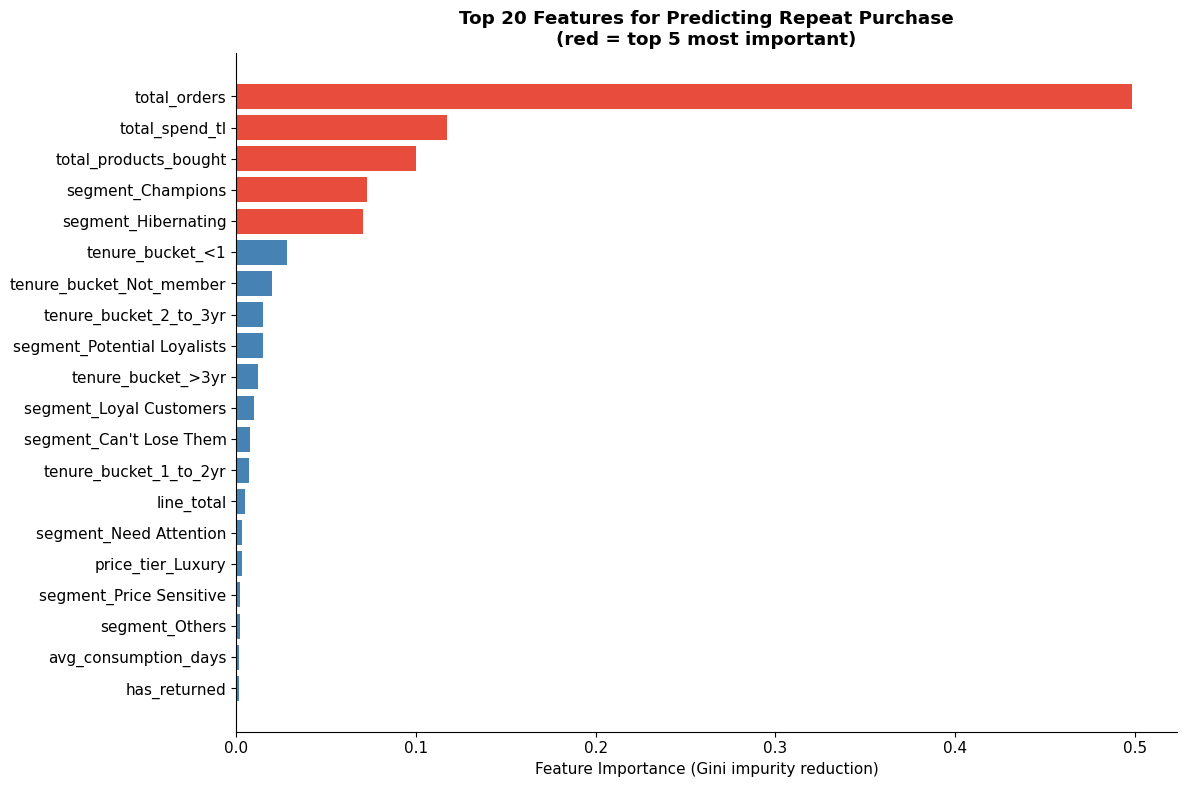


Top 10 features:
                    feature  importance
               total_orders        0.50
             total_spend_tl        0.12
      total_products_bought        0.10
          segment_Champions        0.07
        segment_Hibernating        0.07
           tenure_bucket_<1        0.03
   tenure_bucket_Not_member        0.02
     tenure_bucket_2_to_3yr        0.02
segment_Potential Loyalists        0.01
         tenure_bucket_>3yr        0.01


In [43]:
# Feature importance plot
importances = pd.DataFrame({
    'feature':    feature_matrix.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 20
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if i < 5 else 'steelblue' for i in range(top_n)]
ax.barh(top_features['feature'][::-1],
        top_features['importance'][::-1],
        color=colors[::-1])
ax.set_xlabel('Feature Importance (Gini impurity reduction)')
ax.set_title(f'Top {top_n} Features for Predicting Repeat Purchase\n'
             f'(red = top 5 most important)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_16_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string(index=False))

**Add K-Means to DBScan to create Ensemble Unsupervised Learning**
Adding RFM for initial segmentation -> K-Means for refined clusters -> use segment labels as context for CF model

In [44]:
# K-Means Clustering on Registered Customers
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Prepare features for K-Means (use RFM + behavioral metrics)
kmeans_features = rfm_registered[[
    'recency_days', 'frequency', 'monetary', 'avg_order_value', 'active_days'
]].copy()

# Standardize features so that K-Means isn't biased by scale differences
scaler = StandardScaler()
kmeans_features_scaled = scaler.fit_transform(kmeans_features)

# Determine optimal k using Elbow Method + Silhouette Score - Exhaustive Search because only 1 hyperparameter and small k range
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(kmeans_features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(kmeans_features_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(kmeans_features_scaled, kmeans.labels_))

print("K-Means Optimal k Search Results:")
print("\nK\tInertia\t\tSilhouette\tDavies-Bouldin")
for i, k in enumerate(k_range):
    print(f"{k}\t{inertias[i]:.2f}\t\t{silhouette_scores[i]:.4f}\t\t{davies_bouldin_scores[i]:.4f}")

# Select optimal k (typically highest silhouette + reasonable davies-bouldin)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nRecommended k: {optimal_k} (highest Silhouette Score)")
print(f"- Silhouette: {max(silhouette_scores):.4f} (range: -1 to 1, higher is better)")
print(f"- Davies-Bouldin: {davies_bouldin_scores[optimal_k-2]:.4f} (lower is better)")

# Train final K-Means with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_registered['kmeans_cluster'] = kmeans_final.fit_predict(kmeans_features_scaled)

print(f"\nK-Means trained with k={optimal_k}")
print(f"Cluster distribution:\n{rfm_registered['kmeans_cluster'].value_counts().sort_index()}")

# Analyze K-Means Clusters
print("K-Means Cluster Profiles:")

cluster_profiles = rfm_registered.groupby('kmeans_cluster').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    avg_order_value=('avg_order_value', 'mean'),
    total_revenue=('monetary', 'sum'),
    avg_active_days=('active_days', 'mean')
).round(2)

cluster_profiles['revenue_pct'] = (
    cluster_profiles['total_revenue'] / cluster_profiles['total_revenue'].sum() * 100
).round(1)
cluster_profiles['customer_pct'] = (
    cluster_profiles['customer_count'] / cluster_profiles['customer_count'].sum() * 100
).round(1)

print(cluster_profiles[[
    'customer_count', 'customer_pct', 'revenue_pct',
    'avg_recency', 'avg_frequency', 'avg_monetary', 'avg_order_value'
]].to_string())

# Context Feature Engineering
# Option: Create context features from behavioral data
# (if customer profiles not available, derive from product purchases)

# Get product category purchased most frequently by each customer
product_categories = df.merge(
    registered[['customer_id', 'order_id']], 
    on=['customer_id', 'order_id']
).groupby(['customer_id', 'category_main']).size().reset_index(name='category_purchases')

# Get top category per customer
top_category = product_categories.loc[
    product_categories.groupby('customer_id')['category_purchases'].idxmax()
][['customer_id', 'category_main']]
top_category.columns = ['customer_id', 'primary_category']

rfm_registered = rfm_registered.merge(top_category, on='customer_id', how='left')

print("Context features added:")
print(f"K-Means Cluster: {optimal_k} clusters")
print(f"Primary Product Category: {rfm_registered['primary_category'].nunique()} unique categories")

# Create Final Context Features for NCF-CI Model
# Combine RFM segments + K-Means clusters + product category + behavioral context

rfm_registered['context_segment'] = (
    rfm_registered['segment'] + '(Cluster ' + rfm_registered['kmeans_cluster'].astype(str) + ')'
)

# Create numeric context IDs for model input
segment_to_id = {seg: idx for idx, seg in enumerate(rfm_registered['segment'].unique())}
cluster_to_id = {clust: idx for idx, clust in enumerate(rfm_registered['kmeans_cluster'].unique())}
category_to_id = {cat: idx for idx, cat in enumerate(rfm_registered['primary_category'].unique())}

rfm_registered['segment_id'] = rfm_registered['segment'].map(segment_to_id)
rfm_registered['cluster_id'] = rfm_registered['kmeans_cluster'].map(cluster_to_id)
rfm_registered['category_id'] = rfm_registered['primary_category'].map(category_to_id)

print("\nRFM Segment ID Mapping:")
for seg, seg_id in segment_to_id.items():
    count = (rfm_registered['segment'] == seg).sum()
    print(f"{seg_id}: {seg} ({count} customers)")

print(f"\nK-Means Cluster ID Mapping:")
for clust, clust_id in cluster_to_id.items():
    count = (rfm_registered['kmeans_cluster'] == clust).sum()
    revenue = rfm_registered[rfm_registered['kmeans_cluster'] == clust]['monetary'].sum()
    print(f"{clust_id}: Cluster {clust} ({count} customers, ${revenue:,.0f} revenue)")

print(f"\nPrimary Category ID Mapping:")
for cat, cat_id in category_to_id.items():
    count = (rfm_registered['primary_category'] == cat).sum()
    print(f"{cat_id}: {cat} ({count} customers)")

# Summary Table for Model Input
model_context = rfm_registered[[
    'customer_id',
    'segment', 'segment_id',
    'kmeans_cluster', 'cluster_id',
    'primary_category', 'category_id',
    'recency_days', 'frequency', 'monetary', 'avg_order_value',
    'R_score', 'F_score', 'M_score', 'RFM_score'
]].copy()

print("Sample of final context features for NCF-CI model:")
print(model_context.head(10).to_string())
print(f"\nTotal customers with context features: {len(model_context):,}")

# Save for downstream use in NCF-CI model
model_context.to_csv('customer_context_features.csv', index=False)
rfm_registered.to_csv('rfm_with_kmeans_context.csv', index=False)

K-Means Optimal k Search Results:

K	Inertia		Silhouette	Davies-Bouldin
2	64012.13		0.9835		0.2541
3	46299.84		0.4845		0.7151
4	32335.67		0.3917		0.7620
5	25315.30		0.4165		0.7174
6	22579.79		0.3519		0.8467
7	19779.00		0.3801		0.7911

Recommended k: 2 (highest Silhouette Score)
- Silhouette: 0.9835 (range: -1 to 1, higher is better)
- Davies-Bouldin: 0.2541 (lower is better)

K-Means trained with k=2
Cluster distribution:
kmeans_cluster
0    19150
1        2
Name: count, dtype: int64
K-Means Cluster Profiles:
                customer_count  customer_pct  revenue_pct  avg_recency  avg_frequency  avg_monetary  avg_order_value
kmeans_cluster                                                                                                      
0                        19150        100.00        91.50       302.07           1.85       6304.07          3290.50
1                            2          0.00         8.50         1.00        1169.50    5632376.56          4988.87
Context features 

In [45]:
df.to_csv("/Users/bestek/Desktop/UChicago/Winter'26/ADSP 31017 - ML I/Final Project/clean_data/final_df.csv", index=False)